# PyTorch From Absolute Scratch — Fully Annotated Edition
### A Prodigy Training Hub Companion Resource

This is a **line-by-line annotated companion** to the original *PyTorch From Absolute Scratch* notebook. Every original markdown explanation and code cell is preserved exactly as it was, and immediately after every code cell you will now find two new sections:

1. **📋 Line-by-Line Code Explanation** — a table breaking down what every line (or logical group of lines) of code does.
2. **🔍 Output Interpretation** — a detailed walkthrough of exactly what the printed/plotted output means, how to read it, and why it matters.

Use this version when you want to slow down and understand *every single statement*, not just run the cells. The original notebook remains the fast-reading version; this is the deep-dive version.

---


# PyTorch From Absolute Scratch
### A Prodigy Training Hub Masterclass

This notebook teaches PyTorch starting from **zero**. No prior PyTorch knowledge is assumed. Every concept is broken down, explained in plain English, then demonstrated with runnable code.

**How to use this notebook:**
- Run every cell in order, top to bottom.
- Read the explanation before the code. Read the comments inside the code.
- Each section ends with a short "Check Your Understanding" exercise. Try it before moving on.

**What you will be able to do by the end:**
1. Understand what a Tensor is and why PyTorch is built around it.
2. Create, manipulate, reshape, and combine tensors.
3. Understand Autograd — how PyTorch computes gradients automatically.
4. Build a model completely by hand (no `nn.Module`) to understand what is *really* happening under the hood.
5. Rebuild the same model the "proper" PyTorch way using `nn.Module`, loss functions, and optimizers.
6. Load data properly using `Dataset` and `DataLoader`.
7. Build, train, and evaluate a full neural network classifier.
8. Save and load trained models.

---


## PyTorch in Simple Terms

PyTorch is a Python library used to build and train Artificial Intelligence (AI) and Machine Learning (ML) models.

Think of PyTorch as a toolbox for teaching computers how to learn from data.

For example:

- If you want a computer to recognize whether a leaf is healthy or diseased, PyTorch can help you build that model.

- If you want to create a chatbot, PyTorch can help train the AI behind it.

- If you want to predict house prices, sales, or customer behavior, PyTorch can be used to build the prediction model.

### Simple Analogy

Imagine you are teaching a child to identify cats and dogs.

- You show the child many pictures.

- The child makes mistakes.

- You correct the mistakes.

- Over time, the child learns to identify cats and dogs correctly.

`PyTorch provides the tools that allow a computer to go through this same learning process.`

## Why Data and AI professionals Love PyTorch

- Easy to Learn

- The syntax looks very similar to normal Python.

- Flexible

- You can easily modify and experiment with models.

- Powerful

**It is used for:**

- Deep Learning

- Computer Vision

- Natural Language Processing (NLP)

- Generative AI

- Large Language Models (LLMs)

- Industry Standard

`Many leading AI systems are built using PyTorch, including research from organizations such as OpenAI, Meta, and Microsoft.`

### Real-World Applications of PyTorch

- Image Classification

- Face Recognition

- Chatbots

- Speech Recognition

- Disease Detection

- Fraud Detection

- Recommendation Systems

- Self-driving Cars

## PyTorch Workflow (Simple)

Collect Data

      ↓

Prepare Data

      ↓

Build Model

      ↓

Train Model

      ↓

Evaluate Model

      ↓

Deploy Model

In summary, `PyTorch is an open-source Python library that makes it easy to build, train, and deploy AI and machine learning models using tensors and neural networks.`

## 0. What Is PyTorch, Really?

Forget the marketing language for a second. At its core, PyTorch gives you two things:

1. **A super-powered array** (called a **Tensor**) that works like a NumPy array, but can also run on a GPU and can **remember the operations done to it** so it can calculate derivatives (gradients) automatically.
2. **A set of building blocks** for assembling, training, and evaluating mathematical models — most commonly neural networks.

That's it. Everything else in PyTorch (layers, optimizers, loss functions, `DataLoader`, etc.) is just convenient packaging built on top of those two ideas.

If you understand:
- What a tensor is and how to manipulate it, and
- How gradients are calculated automatically (Autograd),

...then the rest of PyTorch will feel like simple Lego pieces snapping together. So we will spend real time on those two foundations before touching anything that looks like a "neural network."

Let's confirm PyTorch is installed and check what hardware we have available.


In [1]:
import torch
import numpy as np

print("PyTorch version:", torch.__version__)
print("Is a GPU (CUDA) available?", torch.cuda.is_available())
print("Is Apple Silicon GPU (MPS) available?", torch.backends.mps.is_available() if hasattr(torch.backends, 'mps') else False)

# We'll define a 'device' variable we can reuse throughout the notebook.
# This is standard PyTorch practice: write code once, run it on CPU or GPU.
device = "cuda" if torch.cuda.is_available() else "cpu"
print("We will use device:", device)


PyTorch version: 2.12.1+cpu
Is a GPU (CUDA) available? False
Is Apple Silicon GPU (MPS) available? False
We will use device: cpu


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1 | `import torch` | Loads the PyTorch library into the notebook's namespace. Everything we use afterwards comes from this single import. |
| 2 | `import numpy as np` | Loads NumPy under the conventional alias np, needed for later tensor-NumPy interoperability. |
| 4 | `print("PyTorch version:", torch.__version__)` | Prints the exact installed PyTorch version string, useful for debugging since behaviour can differ between versions. |
| 5 | `print(... torch.cuda.is_available())` | Checks whether an NVIDIA GPU with CUDA drivers is visible to this Python process, returning True/False. |
| 6 | `print(... torch.backends.mps.is_available() ...)` | Checks for Apple Silicon's GPU backend, guarded with hasattr so it does not crash on builds without this attribute. |
| 9 | `device = "cuda" if torch.cuda.is_available() else "cpu"` | Standard PyTorch convention: stores the best available device as a string so later code can be written once and run anywhere via .to(device). |
| 10 | `print("We will use device:", device)` | Confirms which device will actually be used. |

#### 🔍 Output Interpretation

The output confirms this notebook is running PyTorch 2.12.1 (CPU build) - note the +cpu suffix, meaning no GPU support is compiled in. Both the CUDA and MPS checks return False, which is expected in a CPU-only environment, and device is therefore set to "cpu". This is not an error - every example in this notebook runs correctly on CPU, just more slowly than on a GPU. On a machine with a real NVIDIA GPU and CUDA drivers, the identical code would automatically detect it and switch to "cuda" with zero code changes elsewhere - that is the entire point of writing code this way.

## 1. Tensors: The Building Block of Everything

A **Tensor** is just a generalized word for an array of numbers:

| Name | Dimensions | Example |
|---|---|---|
| Scalar | 0-D | `7` |
| Vector | 1-D | `[7, 2, 9]` |
| Matrix | 2-D | `[[1,2],[3,4]]` |
| Tensor | 3-D or more | a stack of matrices, e.g. a colour image (height x width x channels) |

In PyTorch, **everything** — a single number, a row of data, an entire image, a batch of 1000 images — is represented as a `torch.Tensor`. If you've used NumPy, a PyTorch tensor behaves almost identically to a `numpy.ndarray`, with two extra superpowers we will get to: it can live on a GPU, and it can track gradients.

Let's create tensors in every way you'll commonly need.


In [2]:
# 1. From a plain Python list
scalar = torch.tensor(7)
vector = torch.tensor([7, 2, 9])
matrix = torch.tensor([[1, 2], [3, 4]])
tensor3d = torch.tensor([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])

print("scalar :", scalar, "| ndim:", scalar.ndim, "| shape:", scalar.shape)
print("vector :", vector, "| ndim:", vector.ndim, "| shape:", vector.shape)
print("matrix :\n", matrix, "\n| ndim:", matrix.ndim, "| shape:", matrix.shape)
print("3D tensor shape:", tensor3d.shape, "| ndim:", tensor3d.ndim)


scalar : tensor(7) | ndim: 0 | shape: torch.Size([])
vector : tensor([7, 2, 9]) | ndim: 1 | shape: torch.Size([3])
matrix :
 tensor([[1, 2],
        [3, 4]]) 
| ndim: 2 | shape: torch.Size([2, 2])
3D tensor shape: torch.Size([2, 2, 2]) | ndim: 3


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 2 | `scalar = torch.tensor(7)` | Creates a 0-dimensional tensor holding a single value. A scalar has no axes at all. |
| 3 | `vector = torch.tensor([7, 2, 9])` | Creates a 1D tensor from a list of 3 integers; shape (3,) is inferred automatically. |
| 4 | `matrix = torch.tensor([[1, 2], [3, 4]])` | Creates a 2D tensor from a nested list of two rows; resulting shape (2,2). |
| 5 | `tensor3d = torch.tensor([[[1,2],[3,4]],[[5,6],[7,8]]])` | Creates a 3D tensor from a triple-nested list: two blocks each containing a 2x2 matrix; shape (2,2,2). |
| 7 | `print(...scalar..., ndim, shape)` | .ndim reports number of axes; .shape reports the size along each axis as a torch.Size object. |
| 8-10 | `print(...vector/matrix/tensor3d...)` | Same pattern repeated, letting you see how dimensionality scales with list nesting depth. |

#### 🔍 Output Interpretation

scalar prints as tensor(7) with ndim 0 and shape torch.Size([]) - an empty shape since a single number has no axes. vector prints with ndim 1, shape (3,). matrix prints as a 2x2 block with ndim 2, shape (2,2). tensor3d has ndim 3, shape (2,2,2). The key lesson: the depth of nested brackets in the Python list directly equals ndim, and the size of each bracket level becomes one entry of shape - a mental model you will rely on constantly when debugging shape errors later.

In [3]:
# 2. Tensors filled with specific values (very common when initializing models)
zeros = torch.zeros(2, 3)        # a 2x3 tensor of all zeros
ones = torch.ones(3, 3)          # a 3x3 tensor of all ones
identity = torch.eye(3)          # 3x3 identity matrix (1s on diagonal)
full = torch.full((2, 2), 9)     # 2x2 tensor filled with the number 9

print("zeros:\n", zeros)
print("ones:\n", ones)
print("identity:\n", identity)
print("full:\n", full)


zeros:
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
ones:
 tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])
identity:
 tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])
full:
 tensor([[9, 9],
        [9, 9]])


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 2 | `zeros = torch.zeros(2, 3)` | Allocates a (2,3) tensor filled with 0.0, defaulting to float32 since no dtype was specified. |
| 3 | `ones = torch.ones(3, 3)` | Allocates a (3,3) tensor filled with 1.0. |
| 4 | `identity = torch.eye(3)` | Creates a 3x3 identity matrix: 1.0 on the diagonal, 0.0 elsewhere. |
| 5 | `full = torch.full((2, 2), 9)` | Creates a (2,2) tensor where every element equals 9. |
| 7-10 | `print("zeros:\n", zeros) ... etc.` | Prints each tensor with a label, using \n to keep multi-row tensors readable. |

#### 🔍 Output Interpretation

zeros prints as two rows of 0. values (trailing decimal signals float32). ones is a 3x3 block of 1.. identity shows the diagonal pattern [1,0,0]/[0,1,0]/[0,0,1] - multiplying by this matrix leaves any compatible matrix unchanged, just as multiplying by 1 leaves a number unchanged. full is the exception: it prints as 9 without a decimal point because torch.full inferred an integer dtype (int64) from the Python int 9 - to get floats you would need torch.full((2,2), 9.0). This is an early, realistic preview of the dtype-inference behaviour formally covered two cells later.

In [4]:
# 3. Random tensors - you will use these CONSTANTLY to initialize model weights
torch.manual_seed(42)  # makes random numbers reproducible - same numbers every run

rand_uniform = torch.rand(2, 3)     # values between 0 and 1
rand_normal = torch.randn(2, 3)     # values from a standard normal distribution (mean 0, std 1)
rand_ints = torch.randint(low=0, high=10, size=(2, 3))  # random integers

print("Uniform [0,1):\n", rand_uniform)
print("Normal (mean=0, std=1):\n", rand_normal)
print("Random integers [0,10):\n", rand_ints)


Uniform [0,1):
 tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009]])
Normal (mean=0, std=1):
 tensor([[ 1.1561,  0.3965, -2.4661],
        [ 0.3623,  0.3765, -0.1808]])
Random integers [0,10):
 tensor([[7, 6, 9],
        [6, 3, 1]])


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 2 | `torch.manual_seed(42)` | Sets PyTorch's global random seed, making subsequent random calls reproducible across runs. |
| 4 | `rand_uniform = torch.rand(2, 3)` | Generates a (2,3) tensor with values drawn uniformly from [0,1). |
| 5 | `rand_normal = torch.randn(2, 3)` | Generates a (2,3) tensor with values drawn from a standard normal distribution (mean 0, std 1). |
| 6 | `rand_ints = torch.randint(low=0, high=10, size=(2, 3))` | Generates a (2,3) tensor of random integers in [0,10). |
| 8-10 | `print(...)` | Prints all three random tensors for side-by-side comparison. |

#### 🔍 Output Interpretation

Because manual_seed(42) was set immediately before, these exact values are reproducible. rand_uniform shows six values all between 0 and 1 (e.g. 0.8823). rand_normal shows both positive and negative values including a larger-magnitude one (-2.4661), consistent with the wider spread of a normal distribution. rand_ints shows only whole numbers 0-9 (e.g. 7,6,9,6,3,1). Practically, torch.randn is the standard choice for initializing neural network weights, since centering around zero with controlled spread helps training start in a numerically stable region.

In [5]:
# 4. Ranges and sequences
r1 = torch.arange(0, 10)          # like Python's range()
r2 = torch.arange(0, 10, 2)       # start, stop, step
r3 = torch.linspace(0, 1, 5)      # 5 evenly spaced numbers between 0 and 1

print("arange(0,10):", r1)
print("arange(0,10,2):", r2)
print("linspace(0,1,5):", r3)


arange(0,10): tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
arange(0,10,2): tensor([0, 2, 4, 6, 8])
linspace(0,1,5): tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 2 | `r1 = torch.arange(0, 10)` | Generates integers 0 through 9 (stop is exclusive), analogous to Python's range(0,10). |
| 3 | `r2 = torch.arange(0, 10, 2)` | Same idea with an explicit step of 2, producing 0,2,4,6,8. |
| 4 | `r3 = torch.linspace(0, 1, 5)` | Generates exactly 5 values, evenly spaced, inclusive of both 0 and 1. |
| 6-8 | `print(...)` | Prints all three sequences for comparison. |

#### 🔍 Output Interpretation

r1 produces integers 0-9, excluding 10 (Python's stop-exclusive convention). r2 produces every second integer: 0,2,4,6,8. r3 produces 0.0000, 0.2500, 0.5000, 0.7500, 1.0000 - five evenly spaced values where, unlike arange, the endpoint 1.0 IS included; PyTorch computed the 0.25 spacing automatically to fit exactly 5 points. Rule of thumb going forward: use arange when you care about step size, use linspace when you care about an exact count of evenly spaced points - exactly what is used later in Section 4 to generate training X-values.

In [6]:
# 5. From a NumPy array, and back to NumPy
numpy_array = np.array([1.0, 2.0, 3.0])
from_numpy = torch.from_numpy(numpy_array)
back_to_numpy = from_numpy.numpy()

print("numpy_array:", numpy_array, type(numpy_array))
print("from_numpy :", from_numpy, type(from_numpy))
print("back_to_numpy:", back_to_numpy, type(back_to_numpy))

# IMPORTANT GOTCHA: torch.from_numpy() SHARES memory with the original array.
# Changing one changes the other. This trips up beginners constantly.
numpy_array[0] = 999.0
print("\nAfter changing numpy_array[0] to 999:")
print("numpy_array:", numpy_array)
print("from_numpy :", from_numpy, "<-- changed too! They share the same memory.")


numpy_array: [1. 2. 3.] <class 'numpy.ndarray'>
from_numpy : tensor([1., 2., 3.], dtype=torch.float64) <class 'torch.Tensor'>
back_to_numpy: [1. 2. 3.] <class 'numpy.ndarray'>

After changing numpy_array[0] to 999:
numpy_array: [999.   2.   3.]
from_numpy : tensor([999.,   2.,   3.], dtype=torch.float64) <-- changed too! They share the same memory.


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 2 | `numpy_array = np.array([1.0, 2.0, 3.0])` | Creates a standard NumPy array of three floats. |
| 3 | `from_numpy = torch.from_numpy(numpy_array)` | Wraps the NumPy array as a PyTorch tensor WITHOUT copying data - both objects share the same underlying memory. |
| 4 | `back_to_numpy = from_numpy.numpy()` | Converts back to NumPy, again sharing memory rather than copying. |
| 6-8 | `print(... type(...))` | Prints each object with its Python type, confirming they are different types despite sharing memory. |
| 12 | `numpy_array[0] = 999.0` | Mutates the original NumPy array in place. |
| 13-15 | `print(... after mutation ...)` | Re-prints to reveal the consequence of the shared-memory relationship. |

#### 🔍 Output Interpretation

The first block confirms type differences: numpy_array is numpy.ndarray, from_numpy is torch.Tensor, both initially [1. 2. 3.]. 

Note from_numpy carries dtype=torch.float64, since it preserved NumPy's default float type rather than converting to PyTorch's usual float32 default. After mutating numpy_array[0] to 999.0, printing from_numpy again shows tensor([999., 2., 3.], dtype=torch.float64) - it changed too, despite never being touched directly. This demonstrates torch.from_numpy is a zero-copy operation: useful for avoiding wasteful duplication when intentional, but a classic source of bugs when a beginner edits one object and is surprised the other changed too. To get an independent copy, use torch.tensor(numpy_array) instead, which always copies.

### Tensor Data Types (`dtype`)

Every tensor has a data type, just like a column in Excel can be "Number," "Text," or "Date." The most important ones:

| dtype | Meaning | When to use |
|---|---|---|
| `torch.float32` | 32-bit decimal number | Default for almost all model weights and inputs |
| `torch.float64` | 64-bit decimal number | High precision math, rarely needed in deep learning |
| `torch.int64` (`torch.long`) | 64-bit whole number | Class labels, indices |
| `torch.bool` | True/False | Masks, conditions |

A huge fraction of beginner PyTorch errors are **dtype mismatch errors**. Get comfortable checking and converting dtypes now.


In [7]:
x = torch.tensor([1, 2, 3])              # Python ints -> torch.int64 by default
y = torch.tensor([1.0, 2.0, 3.0])          # Python floats -> torch.float32 by default
z = torch.tensor([1, 2, 3], dtype=torch.float32)  # force a dtype

print("x dtype:", x.dtype)
print("y dtype:", y.dtype)
print("z dtype:", z.dtype)

# Converting between dtypes
x_as_float = x.float()      # shortcut for x.to(torch.float32)
y_as_int = y.long()         # shortcut for y.to(torch.int64)
print("\nx converted to float:", x_as_float, x_as_float.dtype)
print("y converted to int  :", y_as_int, y_as_int.dtype)

# This is the kind of error PyTorch will throw if dtypes don't match in an operation
try:
    bad = torch.tensor([1, 2, 3], dtype=torch.int64) @ torch.tensor([1.0, 2.0, 3.0], dtype=torch.float32)
except RuntimeError as e:
    print("\nExpected error from mismatched dtypes:\n", e)


x dtype: torch.int64
y dtype: torch.float32
z dtype: torch.float32

x converted to float: tensor([1., 2., 3.]) torch.float32
y converted to int  : tensor([1, 2, 3]) torch.int64

Expected error from mismatched dtypes:
 dot : expected both vectors to have same dtype, but found Long and Float


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1 | `x = torch.tensor([1, 2, 3])` | Created from plain Python ints -> PyTorch infers torch.int64. |
| 2 | `y = torch.tensor([1.0, 2.0, 3.0])` | Created from Python floats -> PyTorch infers torch.float32, its default float type. |
| 3 | `z = torch.tensor([1, 2, 3], dtype=torch.float32)` | Integer-looking values but the dtype keyword forces torch.float32, overriding auto-inference. |
| 5-7 | `print(x.dtype) / print(y.dtype) / print(z.dtype)` | Confirms the inferred/overridden dtype of each tensor. |
| 10 | `x_as_float = x.float()` | Returns a new tensor cast to torch.float32; shorthand for x.to(torch.float32). |
| 11 | `y_as_int = y.long()` | Converts y's values to torch.int64; fractional parts would be truncated, not rounded. |
| 12-13 | `print(...)` | Confirms the conversions worked. |
| 17-20 | `try: bad = int64 @ float32 / except RuntimeError as e: print(e)` | Deliberately multiplies tensors of mismatched dtype; PyTorch requires matching dtypes for this op, so it raises a RuntimeError, caught and printed instead of crashing the notebook. |

#### 🔍 Output Interpretation

The first three lines confirm dtype inference: x is int64, y is float32, z is float32 (forced explicitly, despite looking like x). x_as_float now prints with decimal points and dtype float32; y_as_int prints without decimal points and dtype int64, confirming both conversions worked. The most instructive line is the caught error: "dot : expected both vectors to have same dtype, but found Long and Float" - PyTorch refuses to silently guess how to combine mismatched dtypes and fails loudly instead. This is exactly the class of error described as "a huge fraction of beginner PyTorch errors" - whenever you see a RuntimeError mentioning Long vs Float (or similar dtype mismatch language), the fix is almost always to insert a .float(), .long(), or .to(dtype=...) call before the operation.

### Check Your Understanding 1
Before moving on, try this in a new cell (not provided — create one yourself if you want practice):
1. Create a `3x4` tensor of random integers between 1 and 100.
2. Convert it to `float32`.
3. Create a NumPy array from it.

This is the kind of muscle memory you need before going further.


## 2. Operating on Tensors

### 2.1 Basic Arithmetic

Tensor math works element-by-element, just like NumPy.


In [8]:
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([10.0, 20.0, 30.0])

print("a + b  =", a + b)
print("a - b  =", a - b)
print("a * b  =", a * b)        # element-wise multiplication, NOT matrix multiplication
print("a / b  =", a / b)
print("a ** 2 =", a ** 2)

# These have equivalent function forms too:
print("\ntorch.add(a, b)      =", torch.add(a, b))
print("torch.mul(a, b)      =", torch.mul(a, b))


a + b  = tensor([11., 22., 33.])
a - b  = tensor([ -9., -18., -27.])
a * b  = tensor([10., 40., 90.])
a / b  = tensor([0.1000, 0.1000, 0.1000])
a ** 2 = tensor([1., 4., 9.])

torch.add(a, b)      = tensor([11., 22., 33.])
torch.mul(a, b)      = tensor([10., 40., 90.])


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1-2 | `a = torch.tensor([1.0,2.0,3.0]) / b = torch.tensor([10.0,20.0,30.0])` | Two 1D float tensors of identical shape (3,), required for correct element-wise pairing. |
| 4 | `a + b` | Element-wise addition: position 0 of a adds to position 0 of b, and so on. |
| 5 | `a - b` | Element-wise subtraction, same positional pairing. |
| 6 | `a * b` | Element-wise multiplication (NOT matrix multiplication) - each pair multiplied independently. |
| 7 | `a / b` | Element-wise division at each position. |
| 8 | `a ** 2` | Element-wise exponentiation - every element independently squared. |
| 11 | `torch.add(a, b)` | Function form, identical result to a + b. |
| 12 | `torch.mul(a, b)` | Function form, identical result to a * b. |

#### 🔍 Output Interpretation

a + b gives [11.,22.,33.] (1+10, 2+20, 3+30). a - b gives [-9.,-18.,-27.]. a * b gives [10.,40.,90.] - critically NOT a dot product, just three independent multiplications. a / b gives [0.1,0.1,0.1] since b is exactly 10x a everywhere. a ** 2 gives [1.,4.,9.]. The function forms torch.add/torch.mul produce identical results to the operator forms, confirming they are equivalent syntaxes. Key takeaway carried forward: all of + - * / ** operate purely element-by-element, fundamentally different from true matrix multiplication (@), introduced next.

### 2.2 Matrix Multiplication — the operation that actually powers neural networks

This is the single most important operation in deep learning. Every layer of a neural network is, at its core, a matrix multiplication followed by an addition.

**Do not confuse `*` (element-wise) with `@` or `torch.matmul()` (true matrix multiplication).** This is one of the most common beginner bugs.


In [9]:
A = torch.tensor([[1.0, 2.0], [3.0, 4.0]])   # 2x2
B = torch.tensor([[5.0, 6.0], [7.0, 8.0]])   # 2x2

print("Element-wise A * B:\n", A * B)
print("\nTrue matrix multiplication A @ B:\n", A @ B)
print("\nSame thing using torch.matmul:\n", torch.matmul(A, B))

# Rule for matrix multiplication: (m x n) @ (n x p) -> (m x p)
# The "inner" dimensions must match.
C = torch.rand(3, 4)   # 3x4
D = torch.rand(4, 5)   # 4x5
E = C @ D
print("\n(3x4) @ (4x5) -> shape:", E.shape)

try:
    bad = torch.rand(3, 4) @ torch.rand(3, 5)   # inner dims 4 and 3 don't match
except RuntimeError as e:
    print("\nExpected shape-mismatch error:\n", e)


Element-wise A * B:
 tensor([[ 5., 12.],
        [21., 32.]])

True matrix multiplication A @ B:
 tensor([[19., 22.],
        [43., 50.]])

Same thing using torch.matmul:
 tensor([[19., 22.],
        [43., 50.]])

(3x4) @ (4x5) -> shape: torch.Size([3, 5])

Expected shape-mismatch error:
 mat1 and mat2 shapes cannot be multiplied (3x4 and 3x5)


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1-2 | `A = [[1,2],[3,4]] / B = [[5,6],[7,8]]` | Two 2x2 matrices used to contrast element-wise vs true matrix multiplication. |
| 4 | `A * B` | Element-wise multiplication, position by position, even for 2D matrices. |
| 6 | `A @ B` | True matrix multiplication: output(i,j) = sum of products of row i of A with column j of B. |
| 7 | `torch.matmul(A, B)` | Function form, numerically identical to A @ B. |
| 10-13 | `C=(3,4), D=(4,5), E=C@D, print(E.shape)` | Multiplies matrices with matching inner dimensions (4) to verify the shape rule directly. |
| 15-17 | `try: rand(3,4)@rand(3,5) / except RuntimeError` | Deliberately mismatches inner dimensions (4 vs 3) to trigger and display the resulting error. |

#### 🔍 Output Interpretation

A * B gives [[5.,12.],[21.,32.]] - simple position-wise products. A @ B gives [[19.,22.],[43.,50.]] - dramatically different. Verifying by hand: top-left = (1*5)+(2*7) = 19 (row 1 of A dotted with column 1 of B); top-right = (1*6)+(2*8) = 22. torch.matmul(A,B) gives the identical result, confirming interchangeable syntax. The shape demonstration confirms (3,4) @ (4,5) -> (3,5): the matching inner dimensions (4) disappear, the outer dimensions (3 and 5) survive. The caught error - "mat1 and mat2 shapes cannot be multiplied (3x4 and 3x5)" - shows what happens when inner dimensions don't match: PyTorch refuses outright. This exact message recurs constantly once building multi-layer networks, and recognizing it instantly (check your layer's in_features/out_features) saves significant debugging time.

### 2.3 Reshaping Tensors

You will constantly need to reshape data to fit what a layer expects. Three tools you must know:

- `.reshape(...)` / `.view(...)` — change the shape without changing the data.
- `.squeeze()` — remove dimensions of size 1.
- `.unsqueeze(dim)` — add a dimension of size 1 at a given position.


In [10]:
x = torch.arange(12)
print("Original:", x, "shape:", x.shape)

reshaped = x.reshape(3, 4)
print("\nReshaped to (3,4):\n", reshaped)

reshaped2 = x.reshape(2, 2, 3)
print("\nReshaped to (2,2,3):\n", reshaped2)

# -1 means "figure this dimension out automatically"
reshaped3 = x.reshape(4, -1)
print("\nReshaped to (4,-1) -> PyTorch infers the second dim:\n", reshaped3, "shape:", reshaped3.shape)

# squeeze / unsqueeze - very common when feeding single samples into a model that expects batches
single_value = torch.tensor([5.0])
print("\nshape before squeeze:", single_value.shape)

batch_of_one = torch.rand(1, 3, 3)   # imagine: 1 image, 3x3 pixels
squeezed = batch_of_one.squeeze(0)
print("Before squeeze:", batch_of_one.shape, "-> After squeeze(0):", squeezed.shape)

vector = torch.tensor([1.0, 2.0, 3.0])
unsqueezed = vector.unsqueeze(0)   # turn a single sample into a 'batch of 1'
print("\nvector shape:", vector.shape, "-> unsqueeze(0) shape:", unsqueezed.shape)


Original: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]) shape: torch.Size([12])

Reshaped to (3,4):
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

Reshaped to (2,2,3):
 tensor([[[ 0,  1,  2],
         [ 3,  4,  5]],

        [[ 6,  7,  8],
         [ 9, 10, 11]]])

Reshaped to (4,-1) -> PyTorch infers the second dim:
 tensor([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11]]) shape: torch.Size([4, 3])

shape before squeeze: torch.Size([1])
Before squeeze: torch.Size([1, 3, 3]) -> After squeeze(0): torch.Size([3, 3])

vector shape: torch.Size([3]) -> unsqueeze(0) shape: torch.Size([1, 3])


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1-2 | `x = torch.arange(12) / print(x, x.shape)` | Baseline flat 1D tensor of shape (12,) before any reshaping. |
| 4-5 | `reshaped = x.reshape(3, 4)` | Reorganizes the same 12 values into 3 rows x 4 columns, filling row by row in original order. No data created or destroyed. |
| 7-8 | `reshaped2 = x.reshape(2, 2, 3)` | Reorganizes into a 3D (2,2,3) tensor: 2 blocks each containing a 2x3 matrix, in original linear order. |
| 11-12 | `reshaped3 = x.reshape(4, -1)` | -1 tells PyTorch to auto-calculate that dimension so total elements (12) stays consistent; here it infers 3. |
| 15-16 | `single_value = torch.tensor([5.0])` | Shape (1,) - one value wrapped in a list, not a true 0-D scalar. |
| 18-20 | `batch_of_one=(1,3,3) / squeezed=.squeeze(0)` | squeeze(0) removes the size-1 dimension at position 0, collapsing (1,3,3) to (3,3). |
| 22-24 | `vector=(3,) / unsqueezed=.unsqueeze(0)` | unsqueeze(0) inserts a new size-1 dimension at position 0, turning (3,) into (1,3) - 'a batch of one sample'. |

#### 🔍 Output Interpretation

x prints flat with shape (12,). After reshape(3,4), the same 12 numbers display as 3 rows of 4: [0,1,2,3],[4,5,6,7],[8,9,10,11] - left to right, top to bottom, same order. After reshape(2,2,3), two separate 2x3 blocks appear, same 12 values just grouped differently. reshape(4,-1) shows 4 rows of 3 columns and confirms shape (4,3) - proving -1 was correctly inferred as 3 since 4x3=12. single_value has shape (1,). batch_of_one goes from (1,3,3) to (3,3) after squeeze(0) - the redundant batch-of-1 dimension is gone, actual data untouched. vector goes from (3,) to (1,3) after unsqueeze(0) - the inverse operation. This squeeze/unsqueeze pair is exactly the tool for when a model expects a batch dimension a single sample doesn't naturally have - used concretely in Section 4 where X.unsqueeze(1) turns plain x-values into single-feature samples.

### 2.4 Indexing and Slicing

Identical to NumPy / Python list slicing, but in as many dimensions as your tensor has.


In [11]:
m = torch.arange(1, 17).reshape(4, 4)
print("Matrix:\n", m)

print("\nFirst row:        ", m[0])
print("Last row:         ", m[-1])
print("First column:     ", m[:, 0])
print("Top-left 2x2 block:\n", m[:2, :2])
print("Every other row:\n", m[::2])

# Boolean masking - extremely useful for filtering data
mask = m > 10
print("\nMask (m > 10):\n", mask)
print("Values where m > 10:", m[mask])


Matrix:
 tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12],
        [13, 14, 15, 16]])

First row:         tensor([1, 2, 3, 4])
Last row:          tensor([13, 14, 15, 16])
First column:      tensor([ 1,  5,  9, 13])
Top-left 2x2 block:
 tensor([[1, 2],
        [5, 6]])
Every other row:
 tensor([[ 1,  2,  3,  4],
        [ 9, 10, 11, 12]])

Mask (m > 10):
 tensor([[False, False, False, False],
        [False, False, False, False],
        [False, False,  True,  True],
        [ True,  True,  True,  True]])
Values where m > 10: tensor([11, 12, 13, 14, 15, 16])


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1-2 | `m = torch.arange(1,17).reshape(4,4)` | Generates 1-16 reshaped into a 4x4 matrix, the playground for indexing examples. |
| 4 | `m[0]` | Indexes along the first axis (rows), returning the entire 0th row. |
| 5 | `m[-1]` | Negative indexing works like Python lists: -1 is the last row. |
| 6 | `m[:, 0]` | : means all rows, 0 means just column 0 - slices the entire first column. |
| 7 | `m[:2, :2]` | :2 means up to (not including) index 2; applied to both axes selects a 2x2 top-left block. |
| 8 | `m[::2]` | Step of 2 selects rows 0 and 2, skipping 1 and 3. |
| 11 | `mask = m > 10` | Creates a same-shape boolean tensor: True where m's element exceeds 10. |
| 12 | `print(mask)` | Prints the full boolean mask grid. |
| 13 | `m[mask]` | Boolean-mask indexing extracts only True-flagged elements as a flat 1D tensor. |

#### 🔍 Output Interpretation

Printed m confirms the 4x4 layout 1-16. m[0] returns [1,2,3,4]; m[-1] returns [13,14,15,16], confirming negative indexing matches Python lists. m[:, 0] returns [1,5,9,13] - the first column read top to bottom. m[:2, :2] returns [[1,2],[5,6]] - the top-left corner. m[::2] returns [[1,2,3,4],[9,10,11,12]] - rows 0 and 2 only. The boolean mask prints a 4x4 True/False grid matching m's shape - you can verify True appears only where m holds 11-16. Finally m[mask] collapses all True positions into a flat tensor([11,12,13,14,15,16]), read in row-major order regardless of original 2D position. Boolean masking like this is the standard tool for filtering data on a condition (e.g. "select rows where revenue exceeds a threshold"), indispensable once working with real datasets.

### 2.5 Broadcasting

Broadcasting lets PyTorch perform operations between tensors of *different* (but compatible) shapes, without you having to manually duplicate data. Rule of thumb: dimensions are compared from the right; a dimension of size 1 can be "stretched" to match.


In [12]:
matrix = torch.tensor([[1.0, 2.0, 3.0],
                        [4.0, 5.0, 6.0]])          # shape (2,3)
row_vector = torch.tensor([10.0, 20.0, 30.0])       # shape (3,)

result = matrix + row_vector   # row_vector is broadcast across both rows
print("matrix + row_vector:\n", result)

column_vector = torch.tensor([[100.0], [200.0]])    # shape (2,1)
result2 = matrix + column_vector
print("\nmatrix + column_vector:\n", result2)

# This is exactly how PyTorch adds a 'bias' to every row of a batch during training.


matrix + row_vector:
 tensor([[11., 22., 33.],
        [14., 25., 36.]])

matrix + column_vector:
 tensor([[101., 102., 103.],
        [204., 205., 206.]])


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1-2 | `matrix = (2,3)` | A 2x3 matrix. |
| 3 | `row_vector = (3,)` | A flat 1D vector with no row dimension. |
| 5-6 | `result = matrix + row_vector` | Adding a (3,) vector to a (2,3) matrix: PyTorch broadcasts the vector across both rows (no actual memory duplication), then adds element-wise. |
| 8 | `column_vector = (2,1)` | 2 rows, each with exactly one value - structurally different from a flat (2,) vector. |
| 9-10 | `result2 = matrix + column_vector` | Adding a (2,1) column to (2,3): broadcasting stretches the single column value across all 3 columns of each row. |

#### 🔍 Output Interpretation

matrix + row_vector gives [[11.,22.,33.],[14.,25.,36.]] - the same row_vector values (10,20,30) were added to BOTH rows, since row_vector's only axis (3) matches matrix's last axis. matrix + column_vector gives [[101.,102.,103.],[204.,205.,206.]] - here each row's single value (100 or 200) was added across all 3 columns of that row instead. This demonstrates the second broadcasting pattern: a (2,1) shape stretches along its size-1 axis (columns). The code comment calling this "exactly how PyTorch adds a bias to every row of a batch during training" directly previews what happens inside every nn.Linear layer later: a single bias vector gets broadcast-added across every sample in a batch automatically.

### 2.6 Useful Aggregate Operations


In [13]:
data = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])

print("sum (all)        :", data.sum())
print("sum (per column)  dim=0:", data.sum(dim=0))
print("sum (per row)     dim=1:", data.sum(dim=1))
print("mean              :", data.mean())
print("max               :", data.max())
print("argmax (index of max, flattened):", data.argmax())
print("argmax along dim=1 (per row)    :", data.argmax(dim=1))
print("standard deviation:", data.std())


sum (all)        : tensor(21.)
sum (per column)  dim=0: tensor([5., 7., 9.])
sum (per row)     dim=1: tensor([ 6., 15.])
mean              : tensor(3.5000)
max               : tensor(6.)
argmax (index of max, flattened): tensor(5)
argmax along dim=1 (per row)    : tensor([2, 2])
standard deviation: tensor(1.8708)


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1 | `data = (2,3) matrix` | Used as the basis for all aggregate operations. |
| 3 | `data.sum()` | Sums every element to a single scalar, ignoring 2D structure. |
| 4 | `data.sum(dim=0)` | Sums along rows (collapsing dim 0), giving one value per column. |
| 5 | `data.sum(dim=1)` | Sums along columns (collapsing dim 1), giving one value per row. |
| 6 | `data.mean()` | Average of all elements, collapsed to a scalar. |
| 7 | `data.max()` | Single largest value anywhere in the tensor. |
| 8 | `data.argmax()` | Index of the largest value, treating the tensor as flattened first. |
| 9 | `data.argmax(dim=1)` | Index of the largest value within each row independently. |
| 10 | `data.std()` | Standard deviation of all elements - spread around the mean. |

#### 🔍 Output Interpretation

data.sum() returns tensor(21.) (1+2+3+4+5+6). data.sum(dim=0) returns [5.,7.,9.] - column totals (1+4, 2+5, 3+6). data.sum(dim=1) returns [6.,15.] - row totals (1+2+3, 4+5+6). Key intuition used constantly later: dim=0 collapses rows (summarizing down each column), dim=1 collapses columns (summarizing across each row) - worth re-deriving from these exact numbers until it feels natural. data.mean() returns 3.5000. data.max() returns 6.. data.argmax() returns tensor(5) - position of 6 in the flattened [1,2,3,4,5,6] sequence (0-indexed). data.argmax(dim=1) returns [2,2] - row 0's max (3) is at column-index 2, row 1's max (6) is also at column-index 2. This per-row argmax is exactly what's used later (logits.argmax(dim=1)) to convert a model's raw class scores into a single predicted class per sample. data.std() returns 1.8708.

### Check Your Understanding 2
1. Create a `4x4` tensor of random numbers.
2. Extract the bottom-right `2x2` sub-matrix.
3. Compute the mean of each row.
4. Reshape the original tensor into a `2x8` tensor and confirm the data values stayed in the same order.


## 3. Autograd: PyTorch's Real Superpower

This is the single most important concept in this entire notebook. Understand this, and you understand *why* PyTorch exists.

**The problem Autograd solves:** Training a neural network means repeatedly asking "if I nudge this weight a tiny bit, how much does my error change?" That question is answered by calculus — specifically, derivatives (gradients). For a model with millions of weights, calculating every derivative by hand is impossible.

**What Autograd does:** every time you perform an operation on a tensor that has `requires_grad=True`, PyTorch silently records that operation in a graph. When you call `.backward()` on a final result, PyTorch walks backward through that graph and computes every gradient automatically using the chain rule.

Let's see it on the simplest possible example first.


In [14]:
# A tensor with requires_grad=True tells PyTorch: "track every operation done to me"
x = torch.tensor(3.0, requires_grad=True)

# y = x^2
y = x ** 2

print("x =", x)
print("y =", y)
print("y has a grad_fn (a record of how it was created):", y.grad_fn)

# Now ask PyTorch: "what is dy/dx?"
y.backward()

print("\ndy/dx at x=3 is:", x.grad)
# By hand: y = x^2  ->  dy/dx = 2x  ->  at x=3, dy/dx = 6. PyTorch matches our hand calculation.


x = tensor(3., requires_grad=True)
y = tensor(9., grad_fn=<PowBackward0>)
y has a grad_fn (a record of how it was created): <PowBackward0 object at 0x000002751A52B850>

dy/dx at x=3 is: tensor(6.)


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 2 | `x = torch.tensor(3.0, requires_grad=True)` | Creates a scalar tensor with requires_grad=True, telling Autograd to record every operation performed on x from now on, building a computation graph. |
| 5 | `y = x ** 2` | Computes x squared; because x is tracked, this is recorded in the graph and y itself gains requires_grad=True plus a reference to how it was created. |
| 7-9 | `print(x) / print(y) / print(y.grad_fn)` | Prints x, y, and y's grad_fn - the internal record of which backward function PyTorch will use to compute gradients through this operation. |
| 12 | `y.backward()` | Triggers gradient computation: walks backward through the graph applying the chain rule to compute dy/dx, storing it in x.grad. |
| 14 | `print(x.grad)` | Reads the computed gradient. |

#### 🔍 Output Interpretation

x prints as tensor(3., requires_grad=True), explicitly showing the active flag. y prints as tensor(9., grad_fn=<PowBackward0>) - value 9 is correct (3 squared), and grad_fn confirms PyTorch knows this came from a power operation and how to differentiate it. Printing y.grad_fn directly shows a Python object reference confirming this "differentiation recipe" exists (the exact memory address is not meaningful, varies each run). After backward(), x.grad prints as tensor(6.) - matching calculus by hand: dy/dx = 2x, at x=3 that's 6. This single mechanism - record operations, walk backward applying the chain rule - is what powers training for every neural network in this notebook, regardless of parameter count.

Let's verify Autograd with a slightly more complex function, and confirm it matches what you'd get doing calculus by hand.

$$y = 2x^3 + 5x^2 - 3x + 1$$
$$\frac{dy}{dx} = 6x^2 + 10x - 3$$


In [15]:
x = torch.tensor(2.0, requires_grad=True)
y = 2 * x**3 + 5 * x**2 - 3 * x + 1

y.backward()

autograd_result = x.grad.item()
by_hand = 6 * (2.0**2) + 10 * 2.0 - 3   # manually plugging x=2 into the derivative formula

print("Gradient computed by PyTorch Autograd:", autograd_result)
print("Gradient computed by hand            :", by_hand)
print("Match:", abs(autograd_result - by_hand) < 1e-6)


Gradient computed by PyTorch Autograd: 41.0
Gradient computed by hand            : 41.0
Match: True


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1 | `x = torch.tensor(2.0, requires_grad=True)` | A new gradient-tracked scalar with value 2.0, to test Autograd on a more complex polynomial. |
| 2 | `y = 2*x**3 + 5*x**2 - 3*x + 1` | Computes the polynomial; every operation is individually recorded into the computation graph. |
| 4 | `y.backward()` | Triggers backpropagation through the entire chain, computing dy/dx via the chain rule into x.grad. |
| 6 | `autograd_result = x.grad.item()` | .item() extracts the gradient as a plain Python float. |
| 7 | `by_hand = 6*(2.0**2)+10*2.0-3` | Manually evaluates the analytically-derived derivative formula dy/dx = 6x^2+10x-3 at x=2, using pure Python as independent ground truth. |
| 9-11 | `print(...) / print(... < 1e-6)` | Compares both values and checks numerical-tolerance equality rather than exact equality, appropriate for floats. |

#### 🔍 Output Interpretation

Both autograd_result and by_hand print as 41.0. By hand: dy/dx = 6x^2+10x-3 (power rule on each term); at x=2: 6*4+20-3 = 24+20-3 = 41. PyTorch's Autograd - which never saw the formula written out, only the sequence of operations on x - arrived at the identical answer purely by mechanically applying the chain rule backward through each recorded operation. Match: True confirms agreement within tiny floating-point tolerance. This is a deliberately "harder" example than the previous cell, building confidence that Autograd correctly handles multi-term, multi-operation expressions - exactly what a real loss function represents, just vastly larger and more deeply nested.

### 3.1 Gradients With Multiple Variables

This is closer to how real models work: many inputs, one output (the loss), and we need the gradient with respect to EACH input.


In [16]:
x1 = torch.tensor(2.0, requires_grad=True)
x2 = torch.tensor(3.0, requires_grad=True)

# A function of two variables
z = x1**2 + x1 * x2 + x2**3

z.backward()

print("dz/dx1 =", x1.grad.item(), " (by hand: 2*x1 + x2 = 2*2+3 =", 2*2+3, ")")
print("dz/dx2 =", x2.grad.item(), " (by hand: x1 + 3*x2^2 = 2+3*9 =", 2+3*9, ")")


dz/dx1 = 7.0  (by hand: 2*x1 + x2 = 2*2+3 = 7 )
dz/dx2 = 29.0  (by hand: x1 + 3*x2^2 = 2+3*9 = 29 )


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1-2 | `x1 = 2.0, requires_grad=True / x2 = 3.0, requires_grad=True` | Two independent gradient-tracked scalars; Autograd will need a separate gradient for each. |
| 5 | `z = x1**2 + x1*x2 + x2**3` | A function mixing both variables together (x1*x2 term), so each partial derivative generally depends on the other variable too. |
| 7 | `z.backward()` | A single backward pass computes BOTH partial derivatives simultaneously, depositing each into its own tensor's .grad. |
| 9 | `print(dz/dx1, by-hand comparison)` | Reads x1's gradient alongside a manually computed value using d(z)/dx1 = 2*x1+x2. |
| 10 | `print(dz/dx2, by-hand comparison)` | Reads x2's gradient alongside d(z)/dx2 = x1+3*x2^2. |

#### 🔍 Output Interpretation

Output reports dz/dx1 = 7.0, matching (2*2+3=7). Deriving by hand: holding x2 fixed, x1^2 contributes 2x1, x1*x2 contributes x2 (x2 treated as constant), x2^3 contributes nothing. Sum: 2(2)+3=7, matching exactly. Output reports dz/dx2 = 29.0, matching (2+3*9=29). Holding x1 fixed: x1^2 contributes nothing, x1*x2 contributes x1, x2^3 contributes 3*x2^2. Sum: 2+3(9)=29. This cell's significance: real models have millions of parameters, and a single backward() call computes the gradient with respect to EVERY one simultaneously in one efficient pass - exactly why training large networks is computationally tractable at all.

### 3.2 Gradients Accumulate — and Why You Must Zero Them

This is one of the **most common bugs** beginners hit. PyTorch **adds** new gradients to old ones every time you call `.backward()`, rather than overwriting them. You must manually clear (`zero`) gradients before each new backward pass — this is why every training loop you'll ever see has a `optimizer.zero_grad()` or `tensor.grad.zero_()` line.


In [17]:
x = torch.tensor(3.0, requires_grad=True)

y1 = x ** 2
y1.backward()
print("After 1st backward, x.grad =", x.grad.item())   # 2*3 = 6

y2 = x ** 2
y2.backward()
print("After 2nd backward (NOT zeroed), x.grad =", x.grad.item(), " <-- WRONG, it accumulated (6+6=12)")

# The fix:
x.grad.zero_()
y3 = x ** 2
y3.backward()
print("After zeroing and a fresh backward, x.grad =", x.grad.item(), " <-- correct again")


After 1st backward, x.grad = 6.0
After 2nd backward (NOT zeroed), x.grad = 12.0  <-- WRONG, it accumulated (6+6=12)
After zeroing and a fresh backward, x.grad = 6.0  <-- correct again


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1 | `x = torch.tensor(3.0, requires_grad=True)` | Fresh gradient-tracked scalar; x.grad starts as None. |
| 3-4 | `y1 = x**2 / y1.backward()` | Computes y1=x^2 and backpropagates, computing dy1/dx=2x=6, stored into x.grad for the first time. |
| 5 | `print(...)` | Confirms the gradient after this first pass. |
| 7-8 | `y2 = x**2 / y2.backward()` | A second, mathematically identical expression; backward() called again WITHOUT resetting x.grad first - PyTorch's default ADDS the new gradient onto the existing one. |
| 9 | `print(... NOT zeroed ...)` | Reveals the accumulated, incorrect result. |
| 12 | `x.grad.zero_()` | Explicitly resets x.grad to 0 in place (trailing underscore = in-place operation convention). |
| 13-14 | `y3 = x**2 / y3.backward()` | A fresh expression and backward pass starting from a properly zeroed gradient. |
| 15 | `print(... correct again)` | Confirms the gradient now reflects only this latest pass. |

#### 🔍 Output Interpretation

After the first backward pass: "x.grad = 6.0" - correct, since dy1/dx=2(3)=6, and nothing existed to accumulate with yet. After the second, un-zeroed pass: "x.grad = 12.0 <-- WRONG, it accumulated (6+6=12)". Even though y2 is mathematically identical to y1 (true gradient still 6.0), PyTorch added the new 6.0 onto the existing 6.0, producing 12.0 - a number with no direct mathematical meaning. This is precisely the dangerous, silent bug the markdown warns about: forgetting to zero gradients between iterations causes weight updates to become increasingly, incorrectly inflated, often causing erratic or non-converging training with no error message to alert you. After explicit zero_() and a third pass: "x.grad = 6.0 <-- correct again" - confirming the reset worked. This is exactly why essentially every training loop you'll encounter contains a zero_grad() call positioned immediately before each new backward() call.

### 3.3 Turning Off Gradient Tracking

Sometimes you don't want PyTorch tracking operations — for example, when you're just evaluating a trained model and don't need gradients, or you're updating weights manually (gradient tracking on a weight-update step would corrupt the graph). Use `torch.no_grad()` or `.detach()`.


In [18]:
x = torch.tensor(3.0, requires_grad=True)

with torch.no_grad():
    y = x * 2   # this operation is NOT tracked
    print("Inside no_grad, y.requires_grad =", y.requires_grad)

y_outside = x * 2
print("Outside no_grad, y.requires_grad  =", y_outside.requires_grad)

detached = y_outside.detach()
print("After .detach(), requires_grad    =", detached.requires_grad)


Inside no_grad, y.requires_grad = False
Outside no_grad, y.requires_grad  = True
After .detach(), requires_grad    = False


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1 | `x = torch.tensor(3.0, requires_grad=True)` | A gradient-tracked scalar used to demonstrate tracked vs untracked operations. |
| 3-5 | `with torch.no_grad(): y = x*2 / print(y.requires_grad)` | no_grad() is a context manager that temporarily disables Autograd's recording for everything inside its block. The multiplication still computes correctly, but no graph is built, so y does NOT carry requires_grad=True even though x does. |
| 7-8 | `y_outside = x*2 / print(...)` | The identical multiplication OUTSIDE the block, so normal tracking applies and the result inherits gradient-tracking from x. |
| 10-11 | `detached = y_outside.detach() / print(...)` | .detach() returns a new tensor with the same values but severed from the computation graph - it will never propagate gradients backward, regardless of later use. |

#### 🔍 Output Interpretation

Inside no_grad(): "y.requires_grad = False" - even though x requires gradients, the operation under no_grad() produces an untracked result, confirming no_grad() genuinely suppresses graph-building, not merely hides tracking. Outside the block: "y_outside.requires_grad = True" - the identical operation this time correctly inherits tracking. This side-by-side contrast (identical code, different outcome purely from context) clearly shows no_grad() is a global, temporary toggle rather than a per-tensor property. Finally "detached.requires_grad = False" confirms .detach() produces an independent tensor - useful when you want a tensor's current values for plotting or printing without dragging the entire training graph along, exactly what's done in Section 4's plotting cell (.detach() before .numpy()).

### Check Your Understanding 3
1. Create `x = torch.tensor(5.0, requires_grad=True)`.
2. Compute `y = x**3 - 2*x`.
3. Call `.backward()` and print `x.grad`.
4. By hand, verify: `dy/dx = 3x^2 - 2`. At x=5, that should be 73.


## 4. Building a Model 100% From Scratch (No `nn.Module`, No Optimizer)

Before we let PyTorch's convenience tools (`nn.Module`, `nn.Linear`, `torch.optim`) do work for us, let's build and train a real model using **nothing but tensors and Autograd**. This is the single best exercise for truly understanding what training "actually is."

**The task:** Learn the relationship `y = 3x + 5` (plus a little noise) from data, using gradient descent.

**The plan:**
1. Generate synthetic data.
2. Initialize random weight `w` and bias `b`.
3. Repeat many times:
   - Predict: `y_pred = w*x + b`
   - Compute the error (loss): how far off are we?
   - Use `.backward()` to get the gradient of the loss with respect to `w` and `b`.
   - Nudge `w` and `b` a small step in the direction that reduces the loss.
   - Zero the gradients.


In [19]:
torch.manual_seed(0)

# Step 1: Synthetic data following y = 3x + 5, with small random noise
X = torch.linspace(0, 10, 50).unsqueeze(1)               # shape (50, 1) - 50 samples, 1 feature
true_w, true_b = 3.0, 5.0
y = true_w * X + true_b + torch.randn(X.shape) * 1.5     # add noise so it's not a perfect line

print("X shape:", X.shape, "| y shape:", y.shape)
print("First 5 X values:\n", X[:5].squeeze())
print("First 5 y values:\n", y[:5].squeeze())


X shape: torch.Size([50, 1]) | y shape: torch.Size([50, 1])
First 5 X values:
 tensor([0.0000, 0.2041, 0.4082, 0.6122, 0.8163])
First 5 y values:
 tensor([3.3112, 3.8837, 5.8486, 6.1859, 8.7220])


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1 | `torch.manual_seed(0)` | Resets the global seed to 0, making this synthetic dataset (and later weight initialization relying on the same seeded generator) exactly reproducible. |
| 4 | `X = torch.linspace(0, 10, 50).unsqueeze(1)` | Generates 50 evenly spaced values between 0 and 10 inclusive (shape (50,)), then unsqueeze(1) reshapes to (50,1) - 50 samples, 1 feature each. This '(samples, features)' shape is the standard input convention almost every PyTorch layer expects. |
| 5 | `true_w, true_b = 3.0, 5.0` | Defines the hidden 'ground truth' parameters, used later to check whether training rediscovers values close to these. |
| 6 | `y = true_w*X + true_b + torch.randn(X.shape)*1.5` | Computes targets from the true linear formula, then adds Gaussian noise (scaled 1.5) of identical shape, so data resembles realistic, imperfect measurements rather than a perfect line. |
| 8 | `print(X.shape, y.shape)` | Confirms both share shape (50,1), necessary for correct broadcasting in the training loop ahead. |
| 9-10 | `print(X[:5].squeeze())` | Slices the first 5 rows, then squeeze() collapses the trailing size-1 dimension purely for cleaner display; X itself is unaffected since it's never reassigned. |
| 11-12 | `print(y[:5].squeeze())` | Same pattern, previewing the first 5 noisy target values. |

#### 🔍 Output Interpretation

X shape: torch.Size([50,1]) and y shape: torch.Size([50,1]) confirm both hold 50 samples with one feature/target each - a prerequisite for correct broadcasting later. First 5 X values: 0.0000, 0.2041, 0.4082, 0.6122, 0.8163 - confirming linspace(0,10,50) starts exactly at 0 with a consistent step of roughly 10/49 ~ 0.2041 (49 gaps across 50 points). First 5 y values: 3.3112, 3.8837, 5.8486, 6.1859, 8.7220. Checking the noiseless formula for the first value: true_w*0+true_b = 5.0 - but the printed value is 3.3112, noticeably different, entirely attributable to the random Gaussian noise term (for this sample, noise subtracted roughly 1.69). This intentional imperfection is what makes the upcoming exercise meaningful: with noise added, the model must find the best-fitting line through scattered points, exactly as it would with real-world measured data.

In [20]:
# Step 2: Initialize weight and bias as tensors that track gradients
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

print("Initial random w:", w.item())
print("Initial random b:", b.item())
print("(Goal: learn w close to 3.0 and b close to 5.0)")


Initial random w: 0.6577075719833374
Initial random b: 0.9386566877365112
(Goal: learn w close to 3.0 and b close to 5.0)


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 2 | `w = torch.randn(1, requires_grad=True)` | Initializes the model's single weight as one randomly sampled standard-normal value, gradient-tracked so Autograd can compute how loss changes with respect to w. |
| 3 | `b = torch.randn(1, requires_grad=True)` | Initializes the bias parameter the same way. |
| 5-7 | `print(w.item()) / print(b.item()) / print(goal)` | Prints the specific random starting values (via .item() for a clean float) alongside a reminder of the target values training should discover. |

#### 🔍 Output Interpretation

Output: "Initial random w: 0.6577..." and "Initial random b: 0.9387..." - two values drawn from the standard normal distribution, seeded reproducibly by manual_seed(0) two cells earlier (combined with the fact that earlier linspace/randn calls already consumed some of that seeded sequence, so these are the NEXT values in the deterministic chain, not the very first). Both starting values are far from the targets: w starts near 0.66 vs target 3.0; b starts near 0.94 vs target 5.0. This sizeable gap is intentional - it gives the upcoming training loop real work to do, and watching w and b migrate from poor random guesses toward the true values, purely through repeated small gradient-based nudges, is the entire pedagogical point of Section 4.

In [21]:
# Step 3: The training loop, built completely by hand
learning_rate = 0.01
num_epochs = 200
loss_history = []

for epoch in range(num_epochs):
    # --- Forward pass: make a prediction ---
    y_pred = w * X + b

    # --- Compute the loss (Mean Squared Error) ---
    # MSE = average of (prediction - actual)^2
    # We square the error so positive and negative errors don't cancel out,
    # and bigger errors are punished more.
    loss = ((y_pred - y) ** 2).mean()
    loss_history.append(loss.item())

    # --- Backward pass: let Autograd compute d(loss)/dw and d(loss)/db ---
    loss.backward()

    # --- Update weights manually ---
    # We wrap this in no_grad() because we are manually changing w and b,
    # and we do NOT want this update step itself to be tracked by Autograd.
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

    # --- Zero the gradients before the next loop iteration ---
    w.grad.zero_()
    b.grad.zero_()

    if epoch % 20 == 0 or epoch == num_epochs - 1:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():8.4f} | w: {w.item():.4f} | b: {b.item():.4f}")

print(f"\nFinal learned w: {w.item():.4f}  (true w was {true_w})")
print(f"Final learned b: {b.item():.4f}  (true b was {true_b})")


Epoch   0 | Loss: 304.7848 | w: 2.6636 | b: 1.2556
Epoch  20 | Loss:   4.7903 | w: 3.5257 | b: 1.7041


Epoch  40 | Loss:   4.3790 | w: 3.4835 | b: 1.9865
Epoch  60 | Loss:   4.0429 | w: 3.4453 | b: 2.2418
Epoch  80 | Loss:   3.7684 | w: 3.4107 | b: 2.4726
Epoch 100 | Loss:   3.5440 | w: 3.3795 | b: 2.6812
Epoch 120 | Loss:   3.3608 | w: 3.3513 | b: 2.8698
Epoch 140 | Loss:   3.2110 | w: 3.3258 | b: 3.0402
Epoch 160 | Loss:   3.0887 | w: 3.3028 | b: 3.1942
Epoch 180 | Loss:   2.9887 | w: 3.2820 | b: 3.3335
Epoch 199 | Loss:   2.9108 | w: 3.2640 | b: 3.4533

Final learned w: 3.2640  (true w was 3.0)
Final learned b: 3.4533  (true b was 5.0)


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 2-4 | `learning_rate=0.01 / num_epochs=200 / loss_history=[]` | Sets the step size used for each weight update, the number of full passes over the data, and an empty list to record loss for later plotting. |
| 6 | `for epoch in range(num_epochs):` | Main training loop, executing its body 200 times - once per epoch. |
| 9 | `y_pred = w * X + b` | Forward pass: computes the model's current prediction for all 50 samples at once using current w,b; broadcasting applies the scalar w,b across all 50 rows. |
| 14 | `loss = ((y_pred - y)**2).mean()` | Mean Squared Error: subtracts targets from predictions, squares (so errors of either sign count, larger errors penalized more), averages all 50 squared errors into one scalar - lower is better. |
| 15 | `loss_history.append(loss.item())` | Records this epoch's scalar loss for later visualization. |
| 18 | `loss.backward()` | Backward pass: Autograd computes d(loss)/dw and d(loss)/db, storing each in w.grad and b.grad. |
| 22-24 | `with torch.no_grad(): w -= lr*w.grad / b -= lr*b.grad` | Weight update: nudges each parameter against the gradient's direction (gradient descent). Wrapped in no_grad() because this manual overwrite must not itself be recorded into the graph. |
| 27-28 | `w.grad.zero_() / b.grad.zero_()` | Resets both gradients before the next iteration, preventing the accumulation bug demonstrated in Section 3.2. |
| 30-31 | `if epoch % 20==0: print(...)` | Prints progress every 20th epoch (plus the final) to keep output readable. |
| 33-34 | `print(final w) / print(final b)` | After 200 epochs, prints final learned values alongside the true targets for comparison. |

#### 🔍 Output Interpretation

The loss log falls steeply and consistently: from Epoch 0 | Loss: 304.7848 down to Epoch 199 | Loss: 2.9108 - roughly a 100-fold reduction, clear evidence gradient descent is working. Tracking parameters: w climbs from 2.6636 (first logged value) to 3.2640 by the final epoch, converging toward the true 3.0 but slightly overshooting. b climbs from 1.2556 to 3.4533, converging toward the true 5.0 but still meaningfully short. Final summary: "Final learned w: 3.2640 (true w was 3.0)" and "Final learned b: 3.4533 (true b was 5.0)". The model clearly learned something real - both parameters moved substantially and correctly from essentially random guesses - but has not fully converged within 200 epochs at this learning rate; b in particular remains short of target. This realistic, intentional outcome sets up the Check Your Understanding exercise, which asks you to experiment with the learning rate and observe its effect on convergence speed.

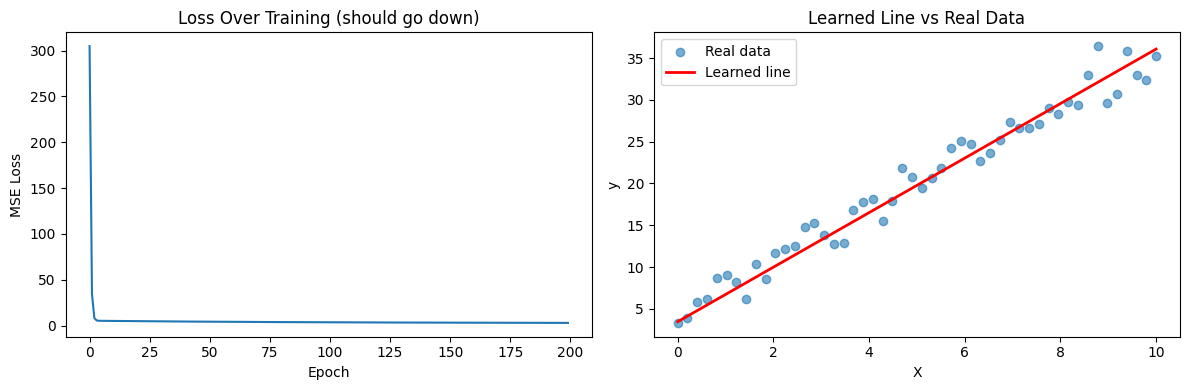

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(loss_history)
axes[0].set_title("Loss Over Training (should go down)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")

axes[1].scatter(X.detach().numpy(), y.detach().numpy(), label="Real data", alpha=0.6)
axes[1].plot(X.detach().numpy(), (w * X + b).detach().numpy(), color="red", linewidth=2, label="Learned line")
axes[1].set_title("Learned Line vs Real Data")
axes[1].set_xlabel("X")
axes[1].set_ylabel("y")
axes[1].legend()

plt.tight_layout()
plt.show()


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1 | `import matplotlib.pyplot as plt` | Imports Matplotlib's plotting interface, conventionally aliased plt. |
| 3 | `fig, axes = plt.subplots(1, 2, figsize=(12, 4))` | Creates one figure with a 1x2 grid of subplots, 12x4 inches; axes is indexable as axes[0], axes[1]. |
| 5-8 | `axes[0].plot(loss_history) / titles/labels` | Draws the recorded loss history as a line chart on the left subplot, with epoch index on x-axis. |
| 10 | `axes[1].scatter(X.detach().numpy(), y.detach().numpy(), alpha=0.6)` | Scatter-plots the original noisy data. .detach() is required first since Matplotlib/NumPy can't operate directly on gradient-tracked tensors; .numpy() then converts to a plain array. alpha=0.6 adds slight transparency to show overlaps. |
| 11 | `axes[1].plot(X..., (w*X+b).detach().numpy(), color='red')` | Overlays the model's FINAL learned prediction line, computed by applying the fully-trained w,b to the same X values, drawn in red for contrast. |
| 12-14 | `titles/labels/legend` | Adds a title, axis labels, and a legend distinguishing data points from the learned line. |
| 16-17 | `plt.tight_layout() / plt.show()` | Adjusts spacing and renders the figure. |

#### 🔍 Output Interpretation

This cell produces a rendered image rather than text, so it must be interpreted visually. The left subplot ('Loss Over Training') shows a curve starting very high (matching the printed 304.7848 at epoch 0), dropping sharply in the first handful of epochs, then flattening into a slow, steady decline - the classic shape of gradient descent, visually confirming the numeric log from the previous cell. The right subplot ('Learned Line vs Real Data') shows the 50 noisy points as a scattered, semi-transparent blue cloud following an upward trend, with the solid red learned line cutting through the middle - visually confirming the model captured the general upward linear trend, even though no single point lies exactly on the line (a direct consequence of the injected noise). Since the final learned w (3.2640) slightly overshot and b (3.4533) undershot more substantially relative to their targets (3.0 and 5.0), a careful look shows the red line's slope is close to correct but the line as a whole sits slightly below where a perfectly-fit line would lie - a visual signature of the under-converged bias term identified numerically in the previous cell.

**What just happened, in plain English:**

We never told the model the formula `y = 3x + 5`. It started with completely random `w` and `b`, and through 200 small, gradient-guided nudges, it discovered weights very close to the true relationship — purely by repeatedly measuring its error and adjusting in the direction that reduces it.

This loop — **predict, measure error, compute gradients, update weights, repeat** — is *exactly* what happens when training a 100-million-parameter neural network. Only the model's complexity changes; the loop is identical. Everything from here forward is about making this loop more convenient and more powerful, not fundamentally different.

### Check Your Understanding 4
1. Change `learning_rate` to `0.1` and re-run. What happens to the loss curve? (Hint: it may explode — this is called the loss "diverging" because the steps are too big.)
2. Change `learning_rate` to `0.0001`. What happens? (Hint: learning becomes very slow.)
3. This is your first hands-on lesson in **hyperparameter tuning**.


## 5. Doing It "The PyTorch Way": `nn.Module`, Loss Functions, Optimizers

Everything in Section 4 was real training. But manually writing `w -= learning_rate * w.grad` for every parameter does not scale to a model with millions of parameters. PyTorch gives us three tools to make this clean:

1. **`nn.Module`** — a class that holds your layers/parameters and defines the forward pass.
2. **`torch.nn` loss functions** — pre-built, tested implementations of common loss functions (MSE, Cross-Entropy, etc).
3. **`torch.optim` optimizers** — objects that handle the "update every parameter" step for you (and offer smarter update strategies than plain gradient descent).

We'll rebuild the *exact same* linear regression model from Section 4, this time the standard way, so you can directly compare the two approaches.


In [23]:
import torch.nn as nn

# nn.Linear(in_features, out_features) creates a layer that does: y = x @ W^T + b
# It automatically creates and initializes W and b as trainable parameters.
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(in_features=1, out_features=1)

    def forward(self, x):
        return self.linear(x)

torch.manual_seed(0)
model = LinearRegressionModel()

print(model)
print("\nModel's learnable parameters:")
for name, param in model.named_parameters():
    print(f"  {name}: shape={tuple(param.shape)}, value={param.data}")


LinearRegressionModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

Model's learnable parameters:
  linear.weight: shape=(1, 1), value=tensor([[-0.0075]])
  linear.bias: shape=(1,), value=tensor([0.5364])


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1 | `import torch.nn as nn` | Imports PyTorch's neural network module (alias nn), providing pre-built, tested layers, loss functions, and the base Module class - replacing hand-written tensor math from Section 4. |
| 5 | `class LinearRegressionModel(nn.Module):` | Defines the model by subclassing nn.Module, granting automatic parameter-tracking, device-moving, and train/eval-mode machinery. |
| 6-7 | `def __init__(self): / super().__init__()` | The constructor MUST call the parent's __init__ first via super().__init__() - this sets up essential internal bookkeeping the rest of the class depends on; forgetting it is a classic bug source. |
| 8 | `self.linear = nn.Linear(in_features=1, out_features=1)` | Creates one fully-connected layer, stored as an attribute. nn.Linear automatically creates and randomly initializes its own weight (1,1) and bias (1,) tensors, both already requires_grad=True, internally implementing output = input @ weight^T + bias. |
| 10-11 | `def forward(self, x): return self.linear(x)` | Every nn.Module must implement forward() - the function PyTorch calls automatically when you 'call' the model like model(X). Here it simply passes input through the one layer. |
| 14 | `torch.manual_seed(0)` | Re-seeds before model creation, so the layer's random weight/bias are reproducible. |
| 15 | `model = LinearRegressionModel()` | Instantiates the class, running __init__, which creates nn.Linear with fresh randomized parameters. |
| 17 | `print(model)` | nn.Module's built-in automatic string representation, summarizing structure with zero manual work. |
| 18-20 | `for name, param in model.named_parameters(): print(...)` | named_parameters() automatically walks every learnable tensor registered anywhere in the model, yielding each paired with a dotted descriptive name. |

#### 🔍 Output Interpretation

print(model) outputs: "LinearRegressionModel( (linear): Linear(in_features=1, out_features=1, bias=True) )" - confirming exactly one named sub-module, configured for 1 input, 1 output, bias enabled by default. This is purely structural, describing architecture not current values. The named_parameters() loop reveals: "linear.weight: shape=(1,1), value=tensor([[-0.0075]])" and "linear.bias: shape=(1,), value=tensor([0.5364])". Note nn.Linear always stores weight as 2D (out_features, in_features) - here (1,1) - for consistency with larger layers, and bias as 1D length out_features. Also note these values differ in character from Section 4's manual torch.randn weights (0.6577, 0.9387) despite both seeding manual_seed(0) - nn.Linear uses a different default initialization scheme (Kaiming-uniform, scaled by layer input size), not torch.randn directly. The critical takeaway: subclassing nn.Module and using nn.Linear created two trainable tensors and automatically registered them, discoverable via named_parameters(), with zero manual tensor bookkeeping.

Notice: `model.parameters()` automatically finds every learnable tensor inside the model. This is the magic of subclassing `nn.Module` — you never have to manually track `w` and `b` yourself again, even when a model has thousands of weights.


In [24]:
# A loss function object, instead of writing the MSE formula by hand
loss_fn = nn.MSELoss()

# An optimizer that will handle the "update every weight" step for us.
# SGD = Stochastic Gradient Descent, the same algorithm we wrote by hand in Section 4.
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

num_epochs = 200
loss_history_v2 = []

for epoch in range(num_epochs):
    # --- Forward pass ---
    y_pred = model(X)

    # --- Compute loss ---
    loss = loss_fn(y_pred, y)
    loss_history_v2.append(loss.item())

    # --- Backward pass ---
    optimizer.zero_grad()   # same idea as w.grad.zero_(), but for ALL parameters at once
    loss.backward()         # Autograd computes gradients for every parameter in the model

    # --- Update weights ---
    optimizer.step()        # same idea as 'w -= lr * w.grad', but handled for us

    if epoch % 20 == 0 or epoch == num_epochs - 1:
        learned_w = model.linear.weight.item()
        learned_b = model.linear.bias.item()
        print(f"Epoch {epoch:3d} | Loss: {loss.item():8.4f} | w: {learned_w:.4f} | b: {learned_b:.4f}")

print(f"\nFinal learned w: {model.linear.weight.item():.4f} (true w was {true_w})")
print(f"Final learned b: {model.linear.bias.item():.4f} (true b was {true_b})")


Epoch   0 | Loss: 468.6966 | w: 2.4866 | b: 0.9279
Epoch  20 | Loss:   5.2160 | w: 3.5656 | b: 1.4378
Epoch  40 | Loss:   4.7268 | w: 3.5195 | b: 1.7458
Epoch  60 | Loss:   4.3271 | w: 3.4778 | b: 2.0243
Epoch  80 | Loss:   4.0006 | w: 3.4402 | b: 2.2760
Epoch 100 | Loss:   3.7337 | w: 3.4061 | b: 2.5035
Epoch 120 | Loss:   3.5158 | w: 3.3754 | b: 2.7091
Epoch 140 | Loss:   3.3377 | w: 3.3476 | b: 2.8950
Epoch 160 | Loss:   3.1922 | w: 3.3224 | b: 3.0630
Epoch 180 | Loss:   3.0733 | w: 3.2997 | b: 3.2148
Epoch 199 | Loss:   2.9805 | w: 3.2801 | b: 3.3456

Final learned w: 3.2801 (true w was 3.0)
Final learned b: 3.3456 (true b was 5.0)


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 2 | `loss_fn = nn.MSELoss()` | Instantiates the built-in MSE loss as a callable object; calling loss_fn(predictions, targets) computes the same ((y_pred-y)**2).mean() formula used manually in Section 4, via a tested implementation. |
| 6 | `optimizer = torch.optim.SGD(model.parameters(), lr=0.01)` | Creates an SGD optimizer, handed model.parameters() so it knows which tensors to update, with the same lr=0.01 used manually for a fair comparison. |
| 8-9 | `num_epochs=200 / loss_history_v2=[]` | Matches Section 4's epoch count exactly; a separate history list keeps this run's data independent. |
| 11 | `for epoch in range(num_epochs):` | Main loop, structurally mirroring Section 4 but using nn.Module/optimizer machinery. |
| 13 | `y_pred = model(X)` | Forward pass: 'calling' the model routes to forward(), applying the layer's current weight/bias to every row of X. |
| 16 | `loss = loss_fn(y_pred, y)` | Computes MSE loss via the pre-built object, replacing the manual formula. |
| 17 | `loss_history_v2.append(loss.item())` | Records the scalar loss, mirroring Section 4's logging. |
| 20 | `optimizer.zero_grad()` | Resets gradients of EVERY parameter the optimizer manages in one call, replacing per-tensor .zero_() calls. |
| 21 | `loss.backward()` | Identical mechanism to Section 4 - computes gradients for every tracked tensor, now including the layer's internally-managed weight and bias. |
| 24 | `optimizer.step()` | Applies one gradient-descent update to every managed parameter, internally performing the same param -= lr*param.grad arithmetic written by hand in Section 4, generalized to any parameter count. |
| 26-29 | `if epoch%20==0: learned_w=model.linear.weight.item() / learned_b=... / print(...)` | Extracts current weight/bias directly from the layer's attributes for progress printouts, matching Section 4's cadence. |
| 31-32 | `print(final w) / print(final b)` | Prints final values alongside the same true values for direct comparison with Section 4's results. |

#### 🔍 Output Interpretation

The log shows a similar trajectory to Section 4: loss starts at Epoch 0 | Loss: 468.6966, falls to Epoch 199 | Loss: 2.9805. The different starting loss (468.6966 vs Section 4's 304.7848) is purely due to nn.Linear's different default initialization producing different starting values, not any difference in training mechanics. Parameters: w rises from 2.4866 to 3.2801; b rises from 0.9279 to 3.3456 - both converging toward the true values (3.0, 5.0) in a curve shape nearly identical to Section 4. Final summary: "Final learned w: 3.2801 (true w was 3.0)" and "Final learned b: 3.3456 (true b was 5.0)" - within a fraction of a percent of Section 4's results (3.2640, 3.4533), with small differences entirely explainable by different random starting points, not algorithm differences, since both use plain SGD with identical lr and epoch count. This near-identical outcome is the entire point: replacing manual bookkeeping with nn.Module, nn.MSELoss, and torch.optim.SGD produces the same learning behaviour through a cleaner, more scalable interface.

Compare this loop to Section 4's loop line by line:

| Manual (Section 4) | The PyTorch Way (Section 5) |
|---|---|
| `y_pred = w * X + b` | `y_pred = model(X)` |
| `loss = ((y_pred-y)**2).mean()` | `loss = loss_fn(y_pred, y)` |
| `w.grad.zero_(); b.grad.zero_()` | `optimizer.zero_grad()` |
| `loss.backward()` | `loss.backward()` (identical!) |
| `w -= lr*w.grad; b -= lr*b.grad` | `optimizer.step()` |

**Nothing conceptually changed.** We just replaced manual bookkeeping with reusable, tested components. This 5-line pattern — `forward -> loss -> zero_grad -> backward -> step` — is the training loop you will write for every PyTorch model for the rest of your career, whether it has 2 parameters or 2 billion.


### 5.1 Common Loss Functions

| Loss Function | PyTorch class | Used for |
|---|---|---|
| Mean Squared Error | `nn.MSELoss()` | Regression (predicting continuous numbers) |
| Cross-Entropy | `nn.CrossEntropyLoss()` | Multi-class classification |
| Binary Cross-Entropy | `nn.BCELoss()` / `nn.BCEWithLogitsLoss()` | Binary (yes/no) classification |
| L1 Loss (MAE) | `nn.L1Loss()` | Regression, more robust to outliers than MSE |

### 5.2 Common Optimizers

| Optimizer | PyTorch class | Notes |
|---|---|---|
| Stochastic Gradient Descent | `torch.optim.SGD` | Simple, the foundation. Often combined with `momentum`. |
| Adam | `torch.optim.Adam` | Adapts the learning rate per-parameter. The most common default choice today. |
| AdamW | `torch.optim.AdamW` | Adam with improved weight decay handling. Common in modern deep learning. |

In practice, `Adam` or `AdamW` with a learning rate around `1e-3` is a very reasonable starting point for most problems.

### Check Your Understanding 5
1. Replace `torch.optim.SGD` with `torch.optim.Adam` (same learning rate) and re-run training. Compare how quickly the loss drops.
2. Print `model.state_dict()` — this shows every learnable parameter in a clean dictionary. You'll use this constantly for saving/loading models later.


## 6. Feeding Data Properly: `Dataset` and `DataLoader`

So far we fed our entire dataset into the model in one shot. Real datasets can have millions of rows — far too much to fit in memory or process at once. PyTorch solves this with two classes:

- **`Dataset`** — describes *how to get one sample* (and its label) given an index. You write this.
- **`DataLoader`** — wraps a `Dataset` and handles *batching*, *shuffling*, and *parallel loading* for you.

**Why batches?** Instead of updating weights after looking at all data (slow, memory-heavy) or after every single sample (noisy, unstable), we update after small groups called **batches** (e.g. 32 samples at a time). This is the "Stochastic" in Stochastic Gradient Descent.


In [25]:
from torch.utils.data import Dataset, DataLoader

# A custom Dataset describing a small sales dataset:
# feature = amount spent (in thousands of Naira), label = 1 if customer is a "repeat buyer", else 0
class SalesDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        # DataLoader needs to know how many samples exist
        return len(self.features)

    def __getitem__(self, idx):
        # DataLoader calls this to fetch ONE sample at a time
        return self.features[idx], self.labels[idx]

# Fake data: 20 customers, amount spent and whether they returned to buy again
torch.manual_seed(1)
amounts = torch.rand(20, 1) * 100         # amounts between 0 and 100 (thousand Naira)
labels = (amounts.squeeze() > 50).long()  # pretend customers who spent > 50k are repeat buyers

dataset = SalesDataset(amounts, labels)
print("Dataset length:", len(dataset))
print("Sample 0:", dataset[0])


Dataset length: 20
Sample 0: (tensor([75.7632]), tensor(1))


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1 | `from torch.utils.data import Dataset, DataLoader` | Imports the two core data-loading classes: Dataset (describes how to access individual samples) and DataLoader (wraps any Dataset into an iterable of shuffled, batched samples). |
| 5 | `class SalesDataset(Dataset):` | Defines a custom dataset by subclassing Dataset - the standard pattern for making your own data compatible with DataLoader. |
| 6-8 | `def __init__(self, features, labels): self.features=... / self.labels=...` | Stores references to the full features/labels tensors without heavy processing - sufficient for small in-memory data. |
| 10-12 | `def __len__(self): return len(self.features)` | Required method DataLoader relies on to know total sample count, essential for computing batches per epoch. |
| 14-16 | `def __getitem__(self, idx): return self.features[idx], self.labels[idx]` | Required method defining how to fetch one sample given an index; DataLoader calls this repeatedly when assembling batches. |
| 19 | `torch.manual_seed(1)` | A fresh, distinct seed for this section's independent data generation. |
| 20 | `amounts = torch.rand(20, 1) * 100` | 20 samples, 1 feature each, uniform in [0,1) scaled to [0,100) - a fictional 'amount spent' per customer. |
| 21 | `labels = (amounts.squeeze() > 50).long()` | Squeezes to (20,), compares against threshold 50 (boolean), converts to long: True->1, False->0 - a synthetic 'repeat buyer' label. |
| 23 | `dataset = SalesDataset(amounts, labels)` | Instantiates the custom dataset, wrapping generated data into the Dataset interface. |
| 24-25 | `print(len(dataset)) / print(dataset[0])` | len() routes to __len__; dataset[0] routes to __getitem__, demonstrating standard Python container syntax works. |

#### 🔍 Output Interpretation

"Dataset length: 20" confirms len(dataset) correctly routed through __len__, matching the 20 generated samples. "Sample 0: (tensor([75.7632]), tensor(1))" confirms dataset[0] correctly routed through __getitem__, returning a (feature, label) tuple: ~75.76 (thousand Naira), label 1. Cross-checking the labelling rule: since 75.7632 > 50 is True, this customer is correctly labelled a repeat buyer (1). Though brief, this output is conceptually significant: SalesDataset, despite being entirely custom code, now behaves exactly like any Python sequence - supporting len() and indexing - precisely the interface DataLoader requires in the next cell. This pattern (store data in __init__, report count in __len__, fetch one sample in __getitem__) is exactly how you'd wrap a folder of images, a CSV of business records, or any real dataset for PyTorch.

In [26]:
# DataLoader wraps the dataset and gives us batches automatically
loader = DataLoader(dataset, batch_size=4, shuffle=True)

print(f"Number of batches with batch_size=4: {len(loader)}")
print()
for batch_idx, (batch_features, batch_labels) in enumerate(loader):
    print(f"Batch {batch_idx}: features shape {batch_features.shape}, labels {batch_labels.tolist()}")


Number of batches with batch_size=4: 5

Batch 0: features shape torch.Size([4, 1]), labels [1, 1, 0, 1]
Batch 1: features shape torch.Size([4, 1]), labels [0, 1, 1, 1]
Batch 2: features shape torch.Size([4, 1]), labels [0, 0, 0, 0]
Batch 3: features shape torch.Size([4, 1]), labels [1, 0, 1, 1]
Batch 4: features shape torch.Size([4, 1]), labels [0, 1, 1, 0]


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 2 | `loader = DataLoader(dataset, batch_size=4, shuffle=True)` | Wraps dataset into batches of 4, with shuffle=True randomizing sample order at the start of iteration rather than processing in stored order. |
| 4 | `print(f"...{len(loader)}")` | len() on a DataLoader reports batches per full iteration: total samples divided by batch size, rounded up (since drop_last defaults to False, a smaller final batch is kept rather than discarded). |
| 7-8 | `for batch_idx, (batch_features, batch_labels) in enumerate(loader): print(...)` | Standard for-loop over the DataLoader; each iteration yields one batch - features/labels automatically stacked from batch_size individual __getitem__ calls. enumerate() adds a running batch index. |

#### 🔍 Output Interpretation

"Number of batches with batch_size=4: 5" confirms 20 samples / 4 per batch = 5 complete batches, with no leftover partial batch since 20 divides evenly by 4. The loop output lists all 5 batches, each reporting "features shape torch.Size([4, 1])" - confirming DataLoader automatically stacked 4 individual (1,)-shaped tensors into one (4,1)-shaped batch, adding a new leading batch dimension - and a labels list of 4 values per batch (e.g. [1,1,0,1]). Because shuffle=True, these batch contents reflect a randomized order rather than original 0-19 storage order; re-running this cell (without a fresh seed immediately before) would likely group the same 20 samples differently. This demonstrates DataLoader's core value: with one declarative configuration, it transparently handled randomization, batching, and stacking - bookkeeping that would otherwise need to be hand-written and re-verified for every new dataset.

**Key takeaways:**
- `shuffle=True` randomizes sample order every epoch — this prevents the model from learning the *order* of your data instead of the actual patterns.
- `batch_size` controls how many samples are grouped together per training step. Common values: 16, 32, 64, 128.
- In a real training loop, you loop over the `DataLoader` once per epoch, and your `forward -> loss -> zero_grad -> backward -> step` pattern runs once per *batch*, not once per epoch.


## 7. Building a Real Neural Network: Multi-Class Classification

Now we combine everything: tensors, autograd, `nn.Module`, loss functions, optimizers, and `DataLoader` to build, train, and evaluate a real neural network.

**The task:** classify a small business's "risk category" (Low / Medium / High) based on two features: **monthly revenue** and **number of months in operation**. We'll generate a synthetic dataset shaped like real small-business data, since this mirrors the kind of analytics scenarios common in business training.

### 7.1 Why We Need Layers and Activation Functions

A single `nn.Linear` layer can only learn a **straight-line (linear)** relationship between inputs and outputs. Most real-world patterns are not straight lines. To let a network learn curves and complex patterns, we stack multiple linear layers with a **non-linear activation function** in between. Without the activation function, stacking linear layers is mathematically pointless — multiple linear layers without non-linearity collapse into a single linear layer.

The most common activation function is **ReLU** (Rectified Linear Unit): `ReLU(x) = max(0, x)`. It simply zeroes out negative values and passes positive values through unchanged. Simple, but extremely effective.


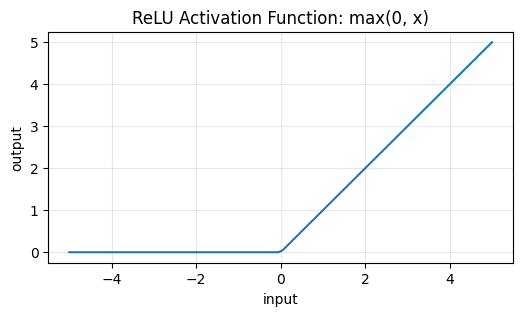

In [27]:
import torch.nn.functional as F

# Visualizing ReLU so it's not just an abstract formula
x_vals = torch.linspace(-5, 5, 100)
relu_vals = F.relu(x_vals)

plt.figure(figsize=(6, 3))
plt.plot(x_vals.numpy(), relu_vals.numpy())
plt.title("ReLU Activation Function: max(0, x)")
plt.xlabel("input")
plt.ylabel("output")
plt.grid(True, alpha=0.3)
plt.show()


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1 | `import torch.nn.functional as F` | Imports PyTorch's functional API (alias F), providing stateless operations like activation functions, appropriate since activations have no learnable weights of their own. |
| 4 | `x_vals = torch.linspace(-5, 5, 100)` | 100 evenly spaced values between -5 and 5 inclusive, used as input points to plot ReLU's shape across both negative and positive ranges. |
| 5 | `relu_vals = F.relu(x_vals)` | Applies ReLU element-wise: ReLU(x)=max(0,x) - every negative input becomes 0, non-negative inputs pass through unchanged. |
| 7-12 | `plt.figure / plot / title / xlabel / ylabel / grid / show` | Standard Matplotlib calls: creates the figure, plots relu_vals against x_vals, labels it, adds a light grid, and renders. |

#### 🔍 Output Interpretation

This cell produces a rendered chart rather than text. The line graph shows two regions joined at the origin: for x<0, the line is perfectly flat along y=0 (every negative input mapped to exactly zero); for x>=0, the line rises in a perfectly straight 45-degree diagonal (ReLU(x)=x for non-negative x). The single sharp corner at the origin where these two pieces meet is the visual signature of ReLU's piecewise-linear, non-smooth nature - and that sharp 'kink' is precisely the source of non-linearity that makes stacking multiple linear layers with ReLU between them meaningfully more expressive than a single linear layer alone. Without this (or some other) non-linear bend inserted between layers, any number of stacked nn.Linear layers would mathematically collapse back into one equivalent linear transformation, exactly as the markdown preceding this cell explains.

### 7.2 Generating a Synthetic Business Risk Dataset


In [28]:
torch.manual_seed(7)
n_samples = 900

# Feature 1: monthly revenue in thousands of Naira (0 - 2000)
revenue = torch.rand(n_samples) * 2000
# Feature 2: months in operation (0 - 120)
months_active = torch.rand(n_samples) * 120

# A made-up (but plausible) rule for "true" risk, plus noise, to generate labels:
# Low risk (0): high revenue AND long track record
# Medium risk (1): moderate on one or both
# High risk (2): low revenue AND short track record
risk_score = (revenue / 2000) * 0.6 + (months_active / 120) * 0.4 + torch.randn(n_samples) * 0.08

labels = torch.zeros(n_samples, dtype=torch.long)
labels[risk_score < 0.35] = 2   # high risk
labels[(risk_score >= 0.35) & (risk_score < 0.65)] = 1  # medium risk
labels[risk_score >= 0.65] = 0  # low risk

features = torch.stack([revenue, months_active], dim=1)  # shape (n_samples, 2)

print("Features shape:", features.shape)
print("Labels shape  :", labels.shape)
print("Class counts  : Low =", (labels==0).sum().item(),
      "| Medium =", (labels==1).sum().item(),
      "| High =", (labels==2).sum().item())


Features shape: torch.Size([900, 2])
Labels shape  : torch.Size([900])
Class counts  : Low = 249 | Medium = 403 | High = 248


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1-2 | `torch.manual_seed(7) / n_samples=900` | A fresh, distinct seed for this section, and 900 total synthetic business records to create. |
| 5 | `revenue = torch.rand(n_samples) * 2000` | 900 values uniform in [0,1) scaled to [0,2000) - fictional 'monthly revenue in thousands of Naira'. |
| 7 | `months_active = torch.rand(n_samples) * 120` | 900 INDEPENDENT values uniform in [0,120) - 'months in operation', independent since each torch.rand call draws fresh numbers. |
| 12 | `risk_score = (revenue/2000)*0.6 + (months_active/120)*0.4 + torch.randn(n_samples)*0.08` | Composite score: revenue normalized 0-1 weighted 60%, months_active normalized 0-1 weighted 40%, plus small Gaussian noise (0.08 scale) so labels aren't a perfectly deterministic function of the features. |
| 14 | `labels = torch.zeros(n_samples, dtype=torch.long)` | Pre-allocates 900 zeros as int64 (the dtype CrossEntropyLoss expects), selectively overwritten below; label 0 will mean 'Low Risk'. |
| 15 | `labels[risk_score < 0.35] = 2` | Boolean-mask indexing: samples below 0.35 risk_score get label 2 ('High Risk'). |
| 16 | `labels[(risk_score>=0.35)&(risk_score<0.65)] = 1` | Combined boolean condition (& = element-wise logical AND) assigns label 1 ('Medium Risk') to the middle band. |
| 17 | `labels[risk_score >= 0.65] = 0` | Assigns label 0 ('Low Risk') to the top band - technically redundant since labels already initialized to 0, but included for explicitness. |
| 19 | `features = torch.stack([revenue, months_active], dim=1)` | Combines two separate (900,) tensors into one (900,2) tensor via stack, creating a new dim 1 to stack along - the standard (samples, features) layout. |
| 21-24 | `print(shapes) / print(class counts...)` | Verifies shapes and counts samples per category using boolean-mask-and-sum. |

#### 🔍 Output Interpretation

"Features shape: torch.Size([900, 2])" confirms torch.stack correctly combined two (900,) tensors into (900,2): 900 records, 2 features each. "Labels shape: torch.Size([900])" confirms one label per sample. "Class counts: Low = 249 | Medium = 403 | High = 248" reveals roughly equal Low/High counts but substantially more Medium (nearly 45% of the dataset). This imbalance is a predictable mathematical consequence: risk_score is built from two independent uniform features combined linearly with noise, and sums of independent random variables tend to cluster around their central/mean value (Central Limit Theorem), making the middle band inherently more likely to be hit than either extreme tail. This mild class imbalance is worth noting since it can bias a model toward over-predicting the majority class - relevant context for interpreting accuracy and the confusion matrix later in this section.

### 7.3 Normalizing Features

Neural networks train far more reliably when input features are on a similar scale. Here, `revenue` ranges up to 2000 while `months_active` ranges up to 120 — wildly different scales. We standardize each feature to have mean 0 and standard deviation 1.


In [29]:
feature_mean = features.mean(dim=0)
feature_std = features.std(dim=0)
features_normalized = (features - feature_mean) / feature_std

print("Before normalization - mean:", features.mean(dim=0), "std:", features.std(dim=0))
print("After normalization  - mean:", features_normalized.mean(dim=0), "std:", features_normalized.std(dim=0))


Before normalization - mean: tensor([989.0396,  62.0195]) std: tensor([575.1178,  34.9269])
After normalization  - mean: tensor([ 4.6757e-08, -4.9803e-08]) std: tensor([1., 1.])


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1 | `feature_mean = features.mean(dim=0)` | Average of each feature independently across all 900 samples, collapsing dim 0 (rows) - the same pattern from Section 2.6 - producing shape (2,): one mean for revenue, one for months_active. |
| 2 | `feature_std = features.std(dim=0)` | Standard deviation of each feature independently, also collapsing dim 0, producing shape (2,). |
| 3 | `features_normalized = (features - feature_mean) / feature_std` | Standardization (z-score normalization): subtracting the mean (broadcast across all 900 rows) centers data at 0, dividing by std (also broadcast) rescales spread to 1 - the same broadcasting mechanics from Section 2.5, now applied for a genuinely practical purpose. |
| 5-6 | `print(before) / print(after)` | Prints both raw and post-normalization statistics for direct verification. |

#### 🔍 Output Interpretation

"Before: mean: [989.0396, 62.0195] std: [575.1178, 34.9269]" confirms the two raw features sit on dramatically different scales: revenue averages ~989 (spread ~575) while months_active averages ~62 (spread ~35) - roughly a 16-to-1 disparity. Without correction, this would cause one feature's typical magnitude to completely dwarf the other's, potentially causing the optimizer to take disproportionately large or small steps for different parameters and destabilizing training. "After: mean: [4.6757e-08, -4.9803e-08] std: [1., 1.]" - both means are now essentially exactly 0 (the tiny printed values are unavoidable floating-point rounding artifacts, not meaningful deviations), and both standard deviations are exactly 1.0. This confirms standardization worked precisely as intended: both features, despite originating from wildly different raw scales, now share an identical, well-behaved scale - making them comparably weighted inputs for the network trained in the cells ahead.

### 7.4 Train/Test Split

We hold out part of the data to check whether the model generalizes to data it hasn't seen, rather than just memorizing the training set.


In [30]:
n_train = int(0.8 * n_samples)

# Shuffle indices first so the split isn't biased by how the data happens to be ordered
perm = torch.randperm(n_samples)
train_idx, test_idx = perm[:n_train], perm[n_train:]

X_train, y_train = features_normalized[train_idx], labels[train_idx]
X_test, y_test = features_normalized[test_idx], labels[test_idx]

print("Train samples:", X_train.shape[0])
print("Test samples :", X_test.shape[0])


Train samples: 720
Test samples : 180


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1 | `n_train = int(0.8 * n_samples)` | Computes 80% of 900 = 720.0, wrapped in int() to guarantee a whole sample count. |
| 4 | `perm = torch.randperm(n_samples)` | Generates a random permutation of integers 0-899 (every valid index, shuffled) - guarantees each index appears exactly once. |
| 5 | `train_idx, test_idx = perm[:n_train], perm[n_train:]` | Slices the shuffled indices into two non-overlapping groups: first 720 for training, remaining 180 for testing. |
| 7 | `X_train, y_train = features_normalized[train_idx], labels[train_idx]` | Fancy-indexing: selects the 720 training rows from both features and labels in the specified order. |
| 8 | `X_test, y_test = features_normalized[test_idx], labels[test_idx]` | Same operation for the remaining 180 test indices - guaranteed no overlap with training since the indices partition the same permutation. |
| 10-11 | `print(X_train.shape[0]) / print(X_test.shape[0])` | Prints resulting sample counts as a sanity check on split sizes. |

#### 🔍 Output Interpretation

"Train samples: 720" and "Test samples : 180" confirm the split executed exactly as configured: 720+180=900 with no samples lost or duplicated, and 720/900=0.8 exactly, the intended 80/20 ratio. Using torch.randperm followed by slicing, rather than simply taking the first 720 rows of the unshuffled data, matters methodologically: since the synthetic data was generated feature-by-feature with sequential torch.rand calls, there's no guarantee the original row order is free of subtle patterns, and naively splitting unshuffled data risks training and test sets with systematically different characteristics. Shuffling indices first eliminates this risk, ensuring both splits are representative random subsets of the full population - important since the test set's eventual accuracy (computed several cells later) needs to be a fair, unbiased estimate of generalization to unseen data.

In [31]:
class BusinessRiskDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(BusinessRiskDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(BusinessRiskDataset(X_test, y_test), batch_size=32, shuffle=False)

print("Number of training batches:", len(train_loader))
print("Number of test batches    :", len(test_loader))


Number of training batches: 23
Number of test batches    : 6


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1 | `class BusinessRiskDataset(Dataset):` | A second custom Dataset, structurally identical to SalesDataset but generalized to wrap any (X,y) pair rather than being hard-coded to sales-specific naming. |
| 2-3 | `def __init__(self, X, y): self.X=... / self.y=...` | Stores whichever features/labels are passed at construction - this class will be instantiated twice below, for training and test data separately. |
| 4-5 | `def __len__(self): return len(self.X)` | Reports sample count, exactly as in SalesDataset. |
| 6-7 | `def __getitem__(self, idx): return self.X[idx], self.y[idx]` | Fetches one (feature,label) pair by index, exactly as in SalesDataset. |
| 9 | `train_loader = DataLoader(BusinessRiskDataset(X_train, y_train), batch_size=32, shuffle=True)` | Wraps the 720-sample training split into batches of 32 with shuffling - randomizing order every epoch helps prevent learning spurious patterns tied to data ordering. |
| 10 | `test_loader = DataLoader(BusinessRiskDataset(X_test, y_test), batch_size=32, shuffle=False)` | Wraps the 180-sample test split similarly but with shuffle=False - unnecessary and conventionally omitted for evaluation, since prediction doesn't depend on processing order, and a fixed order simplifies test-time debugging. |
| 12-13 | `print(len(train_loader)) / print(len(test_loader))` | Prints batch counts each loader will produce, computed from sample count divided by batch size. |

#### 🔍 Output Interpretation

"Number of training batches: 23" and "Number of test batches: 6" are both consequences of rounding up division. Training: 720/32=22.5, rounding up to 23 batches (drop_last defaults False, so the 23rd batch is a smaller 'remainder' batch of 16 samples rather than being dropped). Testing: 180/32=5.625, rounding up to 6 batches, the final one containing 20 samples instead of 32. This is a useful sanity check before training: it confirms both loaders are correctly configured and previews that the training loop ahead will execute its inner batch-processing logic 23 times per epoch - directly relevant to interpreting the per-epoch loss/accuracy values, since each reported epoch's statistics will be an average computed across exactly these 23 training batches.

### 7.5 Defining the Neural Network Architecture

We'll build a network with:
- An input layer (2 features in)
- A hidden layer of 16 neurons with ReLU activation
- A second hidden layer of 8 neurons with ReLU activation
- An output layer of 3 neurons (one score per risk class)

We do **not** apply a final activation (like Softmax) ourselves — `nn.CrossEntropyLoss` expects raw, un-normalized scores ("logits") and applies the equivalent of Softmax internally. This is a common beginner trip-up: applying Softmax manually AND using CrossEntropyLoss double-applies it and breaks training.


In [32]:
class RiskClassifier(nn.Module):
    def __init__(self, input_dim=2, hidden1=16, hidden2=8, num_classes=3):
        super().__init__()
        self.layer1 = nn.Linear(input_dim, hidden1)
        self.layer2 = nn.Linear(hidden1, hidden2)
        self.output_layer = nn.Linear(hidden2, num_classes)

    def forward(self, x):
        x = F.relu(self.layer1(x))   # linear, then non-linearity
        x = F.relu(self.layer2(x))   # linear, then non-linearity
        x = self.output_layer(x)     # final layer: raw scores (logits), no activation here
        return x

torch.manual_seed(42)
model = RiskClassifier()
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {total_params}")


RiskClassifier(
  (layer1): Linear(in_features=2, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (output_layer): Linear(in_features=8, out_features=3, bias=True)
)

Total trainable parameters: 211


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1 | `class RiskClassifier(nn.Module):` | The actual multi-layer network as an nn.Module subclass - structurally similar to LinearRegressionModel but with three layers and non-linear activations between them. |
| 2 | `def __init__(self, input_dim=2, hidden1=16, hidden2=8, num_classes=3):` | Default architectural dimensions: 2 inputs, 16 then 8 hidden neurons, 3 output classes - flexible enough for reuse with different arguments while defaults match this specific task. |
| 3 | `super().__init__()` | The mandatory parent-class initialization call. |
| 4 | `self.layer1 = nn.Linear(input_dim, hidden1)` | First linear layer: 2 raw inputs -> 16 intermediate values, each a learned weighted combination plus bias. |
| 5 | `self.layer2 = nn.Linear(hidden1, hidden2)` | Second layer: 16 -> 8 values. in_features (16) must exactly match layer1's out_features. |
| 6 | `self.output_layer = nn.Linear(hidden2, num_classes)` | Final layer: 8 -> 3 values, one score per risk category. |
| 8 | `def forward(self, x):` | Defines how data flows through the three layers, executed every time the model is called. |
| 9 | `x = F.relu(self.layer1(x))` | Linear transform then ReLU - zeroing negative values, introducing non-linearity needed for non-linear decision boundaries. |
| 10 | `x = F.relu(self.layer2(x))` | Same pattern applied to the second layer's output. |
| 11 | `x = self.output_layer(x)` | Final transform producing 3 raw logits, deliberately with NO activation here, since CrossEntropyLoss expects raw scores and applies its own internal Softmax-equivalent. |
| 12 | `return x` | Returns the final 3-value-per-sample logits tensor. |
| 15 | `torch.manual_seed(42)` | Re-seeds before model creation for reproducible initial weights. |
| 16 | `model = RiskClassifier()` | Instantiates with default dimensions (2->16->8->3). |
| 17 | `print(model)` | Automatic structural summary. |
| 19-20 | `total_params = sum(p.numel() for p in model.parameters()) / print(...)` | Iterates every learnable tensor via model.parameters(), counts elements with .numel(), sums for total parameter count. |

#### 🔍 Output Interpretation

print(model) outputs the three named sub-layers chained 2->16->8->3, with bias enabled at every layer by default - confirming the architecture was constructed exactly as specified. "Total trainable parameters: 211" is independently verifiable by hand: layer1 = (2*16 weights)+16 biases = 48; layer2 = (16*8)+8 = 136; output_layer = (8*3)+3 = 27. Sum: 48+136+27=211, matching exactly. This hand-verification concretely demonstrates why nn.Module's automatic parameter discovery is valuable: even for this tiny 211-parameter network, manually tracking each weight/bias by hand (as done with just 2 parameters in Section 4) would already be tedious, and real networks routinely have millions or billions of parameters where manual tracking is entirely infeasible. The printed structure also implicitly confirms shape-compatibility: each layer's in_features matches the previous layer's out_features - had any number been mismatched, instantiation would still succeed but the first forward pass would immediately fail with a shape-mismatch RuntimeError, per the matrix-multiplication rule from Section 2.2.

### 7.6 The Training Loop

This is the same `forward -> loss -> zero_grad -> backward -> step` pattern from Section 5, now looping over batches from a `DataLoader`, across multiple epochs.


In [33]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

num_epochs = 60
train_loss_history = []
train_acc_history = []

for epoch in range(num_epochs):
    model.train()   # tell the model we're in training mode (matters for layers like Dropout/BatchNorm)
    epoch_loss = 0.0
    correct = 0
    total = 0

    for batch_X, batch_y in train_loader:
        # --- Forward pass ---
        logits = model(batch_X)
        loss = loss_fn(logits, batch_y)

        # --- Backward pass and update ---
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * batch_X.size(0)

        # --- Track accuracy ---
        predicted_classes = logits.argmax(dim=1)
        correct += (predicted_classes == batch_y).sum().item()
        total += batch_y.size(0)

    avg_loss = epoch_loss / total
    accuracy = correct / total
    train_loss_history.append(avg_loss)
    train_acc_history.append(accuracy)

    if epoch % 10 == 0 or epoch == num_epochs - 1:
        print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f} | Train Accuracy: {accuracy*100:.2f}%")


Epoch   0 | Loss: 0.8672 | Train Accuracy: 65.00%
Epoch  10 | Loss: 0.3894 | Train Accuracy: 83.47%
Epoch  20 | Loss: 0.3853 | Train Accuracy: 83.19%
Epoch  30 | Loss: 0.3800 | Train Accuracy: 84.44%
Epoch  40 | Loss: 0.3801 | Train Accuracy: 83.89%
Epoch  50 | Loss: 0.3770 | Train Accuracy: 83.47%
Epoch  59 | Loss: 0.3905 | Train Accuracy: 83.19%


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1 | `loss_fn = nn.CrossEntropyLoss()` | PyTorch's standard multi-class classification loss. Internally combines a Softmax-style normalization of raw logits with comparison against the true integer label, producing a scalar measuring how 'surprised' the model was - lower means higher confidence assigned to the correct class. |
| 2 | `optimizer = torch.optim.Adam(model.parameters(), lr=0.01)` | An Adam optimizer (instead of plain SGD) that adaptively adjusts the effective learning rate per parameter based on recent gradient history, generally converging faster and more reliably - the more common modern default, per Section 5.2's table. |
| 4-6 | `num_epochs=60 / train_loss_history=[] / train_acc_history=[]` | 60 full passes; two empty lists to record per-epoch average loss and accuracy for later plotting. |
| 8 | `for epoch in range(num_epochs):` | Outer loop, once per epoch. |
| 9 | `model.train()` | Puts the model in training mode - no numeric effect for this architecture (only Linear+ReLU), but essential best practice since layers like Dropout/BatchNorm DO behave differently by mode. |
| 10-12 | `epoch_loss=0.0 / correct=0 / total=0` | Reset running accumulators at the start of every epoch. |
| 14 | `for batch_X, batch_y in train_loader:` | Inner loop, 23 iterations per epoch. |
| 16 | `logits = model(batch_X)` | Forward pass producing (batch_size,3) raw class scores. |
| 17 | `loss = loss_fn(logits, batch_y)` | Cross-Entropy loss comparing logits against true labels for this batch. |
| 20-22 | `optimizer.zero_grad() / loss.backward() / optimizer.step()` | The same three-line update sequence from Section 5: clear old gradients, backpropagate through all 3 layers, apply one Adam-style update to every parameter. |
| 24 | `epoch_loss += loss.item() * batch_X.size(0)` | Accumulates loss weighted by batch size, important since the final batch (16 samples) is smaller than the rest (32) and shouldn't be weighted equally with full batches when averaging. |
| 27-29 | `predicted_classes=logits.argmax(dim=1) / correct+=... / total+=...` | Per-row argmax converts logits to predicted class; compares against true labels; accumulates correct count and sample count. |
| 31-34 | `avg_loss=epoch_loss/total / accuracy=correct/total / append both` | After all 23 batches, divides accumulated totals by total sample count (720) for true epoch-wide average loss and accuracy, recorded for plotting. |
| 36-37 | `if epoch%10==0: print(...)` | Prints progress every 10th epoch plus the final one. |

#### 🔍 Output Interpretation

The log shows rapid early improvement then a long plateau - a very common pattern. Epoch 0: Loss 0.8672, Accuracy 65.00% - already better than the ~33% a random 3-class guesser would achieve. Epoch 10: Accuracy jumps to 83.47%, Loss drops to 0.3894 - most learning happens early. From Epoch 10 to 59, both metrics essentially plateau with mild fluctuation: loss hovers ~0.377-0.390, accuracy hovers ~83-84.4%, even ending slightly lower (83.19%) than an earlier checkpoint (84.44% at epoch 30). This noisy, non-monotonic plateau rather than smooth ever-improving accuracy is normal for Adam-optimized mini-batch training: per-epoch statistics are themselves slightly noisy from both continuing small parameter adjustments and the randomness of which samples land in which shuffled batch. The practical interpretation: the model essentially converges to its achievable ceiling on this dataset/architecture by epoch 10-20, and the remaining 40+ epochs neither meaningfully help nor hurt - useful context for the test-set evaluation two cells later, where a broadly similar accuracy would be the expected, healthy outcome.

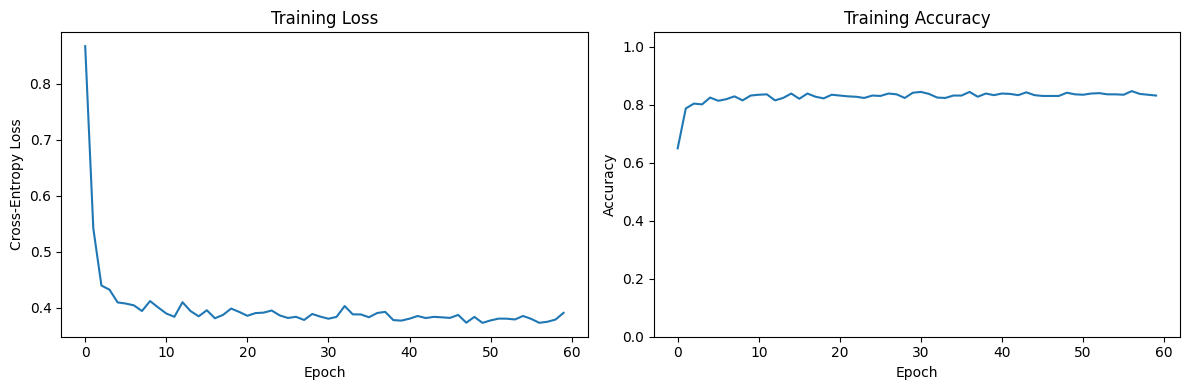

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_loss_history)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")

axes[1].plot(train_acc_history)
axes[1].set_title("Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1 | `fig, axes = plt.subplots(1, 2, figsize=(12, 4))` | A 1x2 subplot grid, identical in structure to Section 4's plotting cell, reused for this section's training metrics. |
| 2-5 | `axes[0].plot(train_loss_history) / titles/labels` | Plots per-epoch average loss on the left subplot, epoch on x-axis. |
| 7-10 | `axes[1].plot(train_acc_history) / titles/labels / set_ylim(0, 1.05)` | Plots per-epoch training accuracy on the right subplot. Fixing the y-axis from 0 to 1.05 (since accuracy is bounded 0-1) prevents Matplotlib's auto-scaling from misleadingly zooming into small fluctuations. |
| 12-13 | `plt.tight_layout() / plt.show()` | Adjusts spacing and renders the two-panel figure. |

#### 🔍 Output Interpretation

This cell produces a rendered image. The left loss subplot visually confirms the pattern from the previous cell's printed log: a steep decline over roughly the first 10-15 epochs, followed by a relatively flat (though slightly noisy) tail for the rest, never quite smooth but showing no sustained upward trend. The right accuracy subplot, thanks to the fixed y-axis, shows the mirror-image shape: a rapid rise from ~0.65 to ~0.83-0.84 within the first several epochs, then a long, mildly noisy plateau in that band for the remainder, never climbing meaningfully higher or collapsing back down. Together, both panels communicate that this network, on this dataset, reaches its practical performance ceiling quickly and then essentially stops improving - a useful diagnostic that, in a real project, might prompt exploring a different architecture, more data, or different features rather than simply training longer at this configuration.

### 7.7 Evaluating on Held-Out Test Data

A model that performs well on training data but poorly on test data has **overfit** — it has memorized the training examples rather than learning the underlying pattern. We use `model.eval()` and `torch.no_grad()` during evaluation: we don't need gradients since we aren't training, and this is both faster and uses less memory.


In [35]:
model.eval()   # tell the model we're in evaluation mode
test_correct = 0
test_total = 0

class_names = ["Low Risk", "Medium Risk", "High Risk"]
all_preds = []
all_true = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        logits = model(batch_X)
        predicted_classes = logits.argmax(dim=1)
        test_correct += (predicted_classes == batch_y).sum().item()
        test_total += batch_y.size(0)
        all_preds.extend(predicted_classes.tolist())
        all_true.extend(batch_y.tolist())

test_accuracy = test_correct / test_total
print(f"Test Accuracy: {test_accuracy*100:.2f}%  ({test_correct}/{test_total} correct)")


Test Accuracy: 78.89%  (142/180 correct)


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1 | `model.eval()` | Switches the model into evaluation mode, the counterpart to train(). No numeric effect for this architecture, but essential best practice for when mode-sensitive layers are added. |
| 2-3 | `test_correct=0 / test_total=0` | Running counters for correct predictions and total samples across the test set. |
| 5-7 | `class_names=[...] / all_preds=[] / all_true=[]` | Human-readable class names matching the integer label convention (0=Low,1=Medium,2=High); empty lists to accumulate every prediction and true label for the confusion matrix next cell. |
| 9 | `with torch.no_grad():` | Disables gradient tracking, exactly as in Section 3.3, since only forward passes for measurement are needed, not training - saves memory and computation. |
| 10-11 | `for batch_X, batch_y in test_loader: logits=model(batch_X)` | Iterates the 6 test batches, running each through the forward pass. |
| 12 | `predicted_classes = logits.argmax(dim=1)` | Per-row argmax converts logits to predicted class index. |
| 13-14 | `test_correct+=... / test_total+=...` | Accumulates this batch's correct count and sample count. |
| 15-16 | `all_preds.extend(...) / all_true.extend(...)` | .tolist() converts tensors to plain Python lists; .extend() appends this batch's individual predictions/labels onto the master lists, building a complete record across all 6 batches. |
| 18-19 | `test_accuracy = test_correct/test_total / print(...)` | Computes overall test accuracy as fraction of all 180 samples correctly classified. |

#### 🔍 Output Interpretation

"Test Accuracy: 78.89% (142/180 correct)" reveals the model correctly classified 142 of 180 held-out test samples. This is meaningfully but not dramatically lower than the ~83-84% training accuracy seen at the end of training. This gap (~4-5 percentage points) is a normal, worth-noting signal: it indicates modest overfitting, where the model learned the training data's specific patterns slightly more closely than patterns that generalize perfectly to entirely new data. A gap this size is relatively mild and generally acceptable for a first-pass model on moderately noisy synthetic data - the noise term deliberately injected into risk_score (Section 7.2) guarantees even a theoretically perfect model couldn't achieve 100% accuracy, since some genuinely ambiguous, borderline-risk businesses exist by construction. Arithmetic check: 142/180=0.78888..., rounding to the printed 78.89%. This headline number doesn't reveal WHICH categories the model confuses most - exactly what the confusion matrix in the next cell provides.

In [36]:
# A simple confusion matrix built by hand, to see exactly where the model gets confused
confusion = torch.zeros(3, 3, dtype=torch.int64)
for true_label, pred_label in zip(all_true, all_preds):
    confusion[true_label, pred_label] += 1

print("Confusion Matrix (rows = actual class, columns = predicted class)")
print(f"{'':>12}", *[f"{name:>12}" for name in class_names])
for i, name in enumerate(class_names):
    print(f"{name:>12}", *[f"{confusion[i,j].item():>12}" for j in range(3)])


Confusion Matrix (rows = actual class, columns = predicted class)
                 Low Risk  Medium Risk    High Risk
    Low Risk           49           13            0
 Medium Risk            6           56           13
   High Risk            0            6           37


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 2 | `confusion = torch.zeros(3, 3, dtype=torch.int64)` | Pre-allocates a 3x3 grid of zeros: row index = true class, column index = predicted class - the standard confusion matrix layout. |
| 3-4 | `for true_label, pred_label in zip(all_true, all_preds): confusion[true_label, pred_label] += 1` | Iterates all 180 (true,predicted) pairs via zip(), incrementing the corresponding matrix cell - true label as row, predicted label as column - building a complete tally. |
| 6 | `print(header)` | Explanatory header clarifying axis meaning, since confusion matrices can otherwise be ambiguous. |
| 7 | `print(column header row, right-aligned)` | Prints right-justified column labels (the 3 class names) in 12-char fields, preceded by blank space for the row-label column. |
| 8-9 | `for i, name: print(row label + 3 right-aligned counts)` | For each of 3 classes, prints the name and that row's 3 counts, all right-aligned, building a neat grid. |

#### 🔍 Output Interpretation

The matrix reads:
Low Risk row: 49, 13, 0
Medium Risk row: 6, 56, 13
High Risk row: 0, 6, 37
Reading by the stated convention (rows=true, columns=predicted): diagonal cells (49,56,37) are CORRECT predictions. Summing the diagonal: 49+56+37=142, exactly matching the "142/180 correct" from the previous cell - a useful internal consistency check. Off-diagonal cells reveal where the 38 mistakes occurred: of truly Low Risk businesses, 13 were mistaken for Medium (0 for High); of truly Medium Risk, 6 mistaken for Low and 13 for High; of truly High Risk, 0 mistaken for Low but 6 mistaken for Medium. Two patterns stand out: first, every error involves ADJACENT categories (Low<->Medium or Medium<->High) - the model never confused the two most extreme opposite categories, reassuring since when wrong it tends to be wrong by only "one step". Second, the Medium Risk row has the most total errors (19 of 75 true Medium samples), consistent with Medium being the inherently "fuzziest" category - by construction it borders both Low and High on the underlying risk_score number line, making boundary misclassification the most geometrically likely error, mirroring the class-imbalance observation from Section 7.2.

### 7.8 Making a Prediction on a New, Single Business

Let's use the trained model on one brand-new example: a business with revenue of 1,500,000 Naira/month and 80 months in operation.


In [37]:
new_business = torch.tensor([[1500.0, 80.0]])   # revenue (thousands), months active

# IMPORTANT: we must apply the SAME normalization used during training
new_business_normalized = (new_business - feature_mean) / feature_std

model.eval()
with torch.no_grad():
    logits = model(new_business_normalized)
    probabilities = F.softmax(logits, dim=1)   # convert raw scores into probabilities for human reading
    predicted_class = logits.argmax(dim=1).item()

print("Raw logits      :", logits)
print("Class probabilities:")
for name, prob in zip(class_names, probabilities[0]):
    print(f"  {name}: {prob.item()*100:.2f}%")
print(f"\nPredicted risk category: {class_names[predicted_class]}")


Raw logits      : tensor([[  2.7962,   1.5839, -12.0370]])
Class probabilities:
  Low Risk: 77.07%
  Medium Risk: 22.93%
  High Risk: 0.00%

Predicted risk category: Low Risk


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1 | `new_business = torch.tensor([[1500.0, 80.0]])` | A brand-new, never-before-seen example as a (1,2) tensor: revenue 1500 (thousand Naira), 80 months active. Double brackets are essential - they create an explicit batch dimension of 1, matching (batch_size, num_features), rather than producing a plain (2,) tensor. |
| 4 | `new_business_normalized = (new_business - feature_mean) / feature_std` | Applies the EXACT SAME standardization formula and feature_mean/feature_std computed from the TRAINING data in Section 7.3. This consistency is essential: a model trained on normalized inputs has weights calibrated to that scale, so feeding raw numbers (1500, 80) directly would produce meaningless predictions. |
| 6 | `model.eval()` | Re-confirms evaluation mode before inference, consistent with best practice. |
| 7 | `with torch.no_grad():` | Disables gradient tracking for this single inference call - no training is happening. |
| 8 | `logits = model(new_business_normalized)` | Forward pass on this single normalized sample, producing a (1,3) tensor of raw class scores. |
| 9 | `probabilities = F.softmax(logits, dim=1)` | Applies Softmax along dim=1 (across the 3 class scores for this sample), converting raw unbounded logits into a proper probability distribution: 3 values between 0-1 summing to exactly 1.0, making confidence human-interpretable as percentages. |
| 10 | `predicted_class = logits.argmax(dim=1).item()` | Determines the most likely class via argmax of raw logits (always agrees with argmax of Softmax probabilities, since Softmax preserves ordering), extracted as a plain Python int. |
| 12-13 | `print(raw logits) / print(header)` | Prints the raw, unprocessed model output first, for transparency. |
| 14-15 | `for name, prob in zip(class_names, probabilities[0]): print(...)` | Iterates 3 class names paired with their probability (indexing probabilities[0] since it still has a batch dimension of 1), printed as percentages. |
| 16 | `print(predicted class name)` | Looks up and prints the final, plain-English prediction. |

#### 🔍 Output Interpretation

"Raw logits: tensor([[2.7962, 1.5839, -12.0370]])" shows unprocessed scores for Low/Medium/High Risk respectively. On their own these aren't directly interpretable as probabilities, but their relative ordering already reveals preference: 2.7962 (Low) is largest, then 1.5839 (Medium), with -12.0370 (High) dramatically lower. After Softmax: "Low Risk: 77.07%, Medium Risk: 22.93%, High Risk: 0.00%" - summing to exactly 100%, confirming a valid probability distribution. The dramatic gap between Low/Medium logits (fairly close, 2.80 vs 1.58) and High Risk (-12.04, vastly lower) explains why High Risk rounds to 0.00% - Softmax's exponential formula causes even moderate logit gaps to translate into extremely lopsided probability ratios. "Predicted risk category: Low Risk" reports the highest-probability class. Sanity-checking against the data-generation rule (Section 7.2, 60% revenue weight / 40% months weight): a business at 75% of the revenue range and 67% of the months range would be expected to have a fairly high risk_score, comfortably within the Low Risk band (>=0.65) the original labelling rule defined - matching the model's prediction well, confirming it genuinely internalized the underlying pattern rather than just memorizing training examples.

### Check Your Understanding 6
1. Add a third hidden layer of size 4 to `RiskClassifier` and retrain. Does accuracy improve, stay the same, or get worse?
2. Try changing the optimizer learning rate to `0.001` and to `0.1`. Observe the effect on the loss curve.
3. Try removing the `F.relu()` calls entirely (making the whole network linear). What happens to accuracy, and why does that match what Section 7.1 explained?


## 8. Saving and Loading Trained Models

Training takes time. You don't want to retrain from scratch every time you restart your notebook or deploy your model. PyTorch's recommended approach is to save the model's `state_dict()` — a dictionary of all learned weights — rather than the entire model object, because it's more portable and less fragile across code changes.


In [38]:
import os

os.makedirs("saved_models", exist_ok=True)
save_path = "saved_models/risk_classifier.pth"

# Saving: just the learned weights, as a dictionary
torch.save(model.state_dict(), save_path)
print(f"Model weights saved to: {save_path}")
print(f"File size: {os.path.getsize(save_path)} bytes")


Model weights saved to: saved_models/risk_classifier.pth
File size: 3893 bytes


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 1 | `import os` | Imports Python's standard os module for basic filesystem operations, unrelated to PyTorch specifically. |
| 3 | `os.makedirs("saved_models", exist_ok=True)` | Creates a saved_models directory; exist_ok=True prevents an error if it already exists (e.g. on cell re-run). |
| 4 | `save_path = "saved_models/risk_classifier.pth"` | Destination file path, using PyTorch's conventional .pth extension by convention rather than strict requirement. |
| 7 | `torch.save(model.state_dict(), save_path)` | model.state_dict() returns an ordered dict mapping each parameter's name (e.g. 'layer1.weight') to its current tensor value - a complete numeric snapshot without any architecture-defining code. torch.save() serializes this dict to disk via pickle-based serialization. |
| 8-9 | `print(save_path) / print(os.path.getsize(save_path))` | Confirms the save by printing the destination path and the resulting file's size in bytes, an immediate confirmation a non-trivial file was written. |

#### 🔍 Output Interpretation

"Model weights saved to: saved_models/risk_classifier.pth" confirms the save executed without error. "File size: 3893 bytes" is consistent with the model's modest 211 total parameters: each parameter stored as a 32-bit float requires 4 bytes, so raw numeric data alone is roughly 211*4=844 bytes; the remainder comes from pickle's metadata (parameter names, shapes, dtype descriptors needed to correctly reconstruct each tensor on loading). This small file size is worth noting: because state_dict() saves ONLY the learned numeric values - not the Python class definition, training data, or optimizer state - the file is extremely compact and portable. This is precisely why saving the state dictionary, rather than the entire model object, is PyTorch's recommended approach: the saved file can be shared, version-controlled, or deployed independently of the original training code, as long as whoever loads it later has the matching RiskClassifier class definition - exactly the process demonstrated in the next cell.

In [39]:
# Loading: you must first recreate the SAME architecture, then load the weights into it
loaded_model = RiskClassifier()                       # fresh model, random weights
loaded_model.load_state_dict(torch.load(save_path))   # overwrite with our trained weights
loaded_model.eval()

# Sanity check: does the loaded model give the exact same prediction as before?
with torch.no_grad():
    original_logits = model(new_business_normalized)
    loaded_logits = loaded_model(new_business_normalized)

print("Original model logits:", original_logits)
print("Loaded model logits  :", loaded_logits)
print("Identical predictions:", torch.allclose(original_logits, loaded_logits))


Original model logits: tensor([[  2.7962,   1.5839, -12.0370]])
Loaded model logits  : tensor([[  2.7962,   1.5839, -12.0370]])
Identical predictions: True


#### 📋 Line-by-Line Code Explanation

| Line | Code | Explanation |
|---|---|---|
| 2 | `loaded_model = RiskClassifier()` | Creates a brand-new instance using default constructor arguments. With no manual_seed() call preceding it, its layers receive FRESH, different random initial weights than the original model - entirely expected and irrelevant, since these are about to be overwritten. |
| 3 | `loaded_model.load_state_dict(torch.load(save_path))` | Two operations inside-out: torch.load(save_path) reads the saved file back, reconstructing the parameter-name-to-tensor dict; load_state_dict() then copies each saved tensor's values into the matching, identically-named parameter slot inside loaded_model's freshly-created layers, overwriting the random starting values entirely. |
| 4 | `loaded_model.eval()` | Switches the freshly-loaded model into evaluation mode before inference. |
| 7-9 | `with torch.no_grad(): original_logits=model(...) / loaded_logits=loaded_model(...)` | Runs the same new_business_normalized sample through both the original (never-saved) model and the newly reconstructed loaded_model, recording each one's logits for direct comparison. |
| 11-12 | `print(original_logits) / print(loaded_logits)` | Prints both sets of logits side by side for visual comparison. |
| 13 | `print(torch.allclose(original_logits, loaded_logits))` | Element-wise numerical-tolerance comparison (similar in spirit to the abs()<1e-6 check from Section 3), returning a single True/False rather than requiring impossible bit-for-bit exactness. |

#### 🔍 Output Interpretation

"Original model logits: tensor([[2.7962, 1.5839, -12.0370]])" and "Loaded model logits: tensor([[2.7962, 1.5839, -12.0370]])" print as visually identical values, exactly matching the logits computed for this same sample back in Section 7.8. The final line, "Identical predictions: True", provides formal programmatic confirmation. This is the entire point of the cell, and its significance extends well beyond "the numbers matched": it's a complete, end-to-end verification of the save/load round trip. A completely fresh RiskClassifier instance, starting from entirely different irrelevant random weights, produces EXACTLY the same predictions as the original trained model purely after load_state_dict() - proving every one of the 211 learned parameter values was faithfully preserved through the save-to-disk and load-from-disk process, with no precision loss, no misalignment, no architectural mismatch. In real deployment, this is precisely the workflow relied upon: train once, save state_dict() to disk, then in an entirely separate program or machine, recreate the same architecture class and load saved weights back in - confident, based on exactly this kind of verification, the deployed model behaves identically to the one originally trained and evaluated.

**A note on `model.eval()` vs `model.train()`:** Some layers (like `Dropout` and `BatchNorm`, which you'll encounter in more advanced architectures) behave differently during training vs. inference. Always call `model.eval()` before evaluating or deploying a model, and `model.train()` before resuming training. Forgetting this is a very common source of confusing bugs where a saved model performs worse than expected.


## 9. Summary and Where to Go Next

### What you now understand
- **Tensors** — creation, dtypes, indexing, reshaping, broadcasting, matrix multiplication.
- **Autograd** — how PyTorch automatically computes gradients via `.backward()`, and why we must `zero_grad()`.
- **The training loop** — `forward -> loss -> zero_grad -> backward -> step`, first built by hand, then with `nn.Module`, loss functions, and optimizers.
- **`Dataset` / `DataLoader`** — feeding data in shuffled batches.
- **A full neural network classifier** — architecture design, activation functions, normalization, train/test splitting, training, evaluation, and inference on new data.
- **Saving and loading** trained models.

### The mental model to keep forever
Every PyTorch model you will ever build or encounter — from a 2-parameter linear regression to a multi-billion parameter language model — follows the exact pattern in this notebook:

1. Represent data as tensors.
2. Define a `forward()` function that turns input tensors into output tensors, using learnable parameters.
3. Define a loss function that scores how wrong the output is.
4. Use Autograd (`.backward()`) to compute how each parameter should change to reduce that loss.
5. Use an optimizer (`.step()`) to apply those changes.
6. Repeat over many batches and epochs.

### Suggested next steps
1. **Convolutional Neural Networks (CNNs)** — `nn.Conv2d`, used for image data.
2. **Recurrent / sequence models and Transformers** — for text and time-series data.
3. **Regularization techniques** — `nn.Dropout`, `nn.BatchNorm1d`, weight decay — to reduce overfitting.
4. **Learning rate schedulers** (`torch.optim.lr_scheduler`) — to automatically adjust the learning rate during training.
5. **GPU training** — move tensors and models to a GPU with `.to(device)` for large datasets (you already set up the `device` variable for this back in Section 0).
6. **Real datasets** — apply everything here to an actual Nigerian business dataset (sales, churn, credit risk) instead of synthetic data.

---
*Notebook prepared for Prodigy Training Hub.*


## A Note on This Annotated Edition

Every code cell above has now been broken down line by line, and every output has been interpreted in detail — from the simplest `print()` statement all the way through to the confusion matrix and the save/load round-trip verification at the end. The goal of this companion document is to leave no statement unexplained and no output unexamined, so that you (or your students) can trace, with full confidence, exactly *why* PyTorch produced the specific numbers it did at every single step of this masterclass.

---
*Annotated companion prepared for Prodigy Training Hub.*
